# P01 — ¿Dónde se agrupan las atenciones y qué cambia al mirar abejas?

## Objetivos
- Distinguir agrupaciones de puntos, puntos calientes de conteos y asociación entre sitios vecinos.
- Reproducir los cambios de población y parámetros de la demostración, sin comparar muestras diferentes como si fueran la misma.
- Interpretar mapas y Moran sin convertir significancia en riesgo ni un máximo en un radio óptimo.

**Docente:** Fabian Cetina. Una fila es una atención registrada de Bomberos de Bogotá, no una colmena ni una emergencia única certificada.

Seleccione el kernel **Python de ArcGIS Pro 3.6 con licencia** y reinicie antes de ejecutar todo. El notebook es autónomo. Abra desde su carpeta o dentro del proyecto. Si trabaja fuera, sustituya la asignación de `ROOT` por `Path("ruta de su proyecto")`. `DATA_DIR`, `PREPARED_JURIS` y `OUTPUT_DIR` admiten ubicaciones externas autorizadas; mantenga entradas y salidas separadas. No necesita AGENTS.md.

**Estado:** recorrido ejecutado; pendiente de revisión académica humana. Las cifras junto a las salidas corresponden a la ejecución indicada al final.

**Ejecución Jupyter: 25/25 celdas completadas, 0 errores de celda, salidas guardadas. Advertencia: el kernel abortó al cerrar; este problema del entorno no está resuelto.**

Corrida del 17/09/2026 (UTC), kernel real Python de ArcGIS Pro. [Registro](<../salidas_clase_02/ejecucion_jupyter_20260917/reintento_3a2b2b37dc/P01/execution.json>) · [Error de cierre](<../salidas_clase_02/ejecucion_jupyter_20260917/reintento_3a2b2b37dc/P01/kernel.stderr.log>).

In [1]:
# Edite aquí las rutas; cada ejecución tendrá su propia carpeta.
from pathlib import Path
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / 'README.md').is_file() and (p / '99 - Recursos/notebooks').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Abra dentro del proyecto o asigne ROOT = Path("ruta de su proyecto").')
DATA_DIR = ROOT / 'Datos'
PREPARED_JURIS = ROOT / '99 - Recursos/datos/p02_jurisdicciones_preparadas/jurisdicciones.gdb/Jurisdicciones_Bomberos'
OUTPUT_DIR = ROOT / '99 - Recursos/salidas_clase_02/practica_01/reorganizacion_20260917'


## Primero, ¿qué contiene la tabla?
La fuente combina servicios y años. **Nulo** significa ausente; **cero** es un valor registrado. Una clave repetida o dos coordenadas iguales no prueban duplicación: pueden ser visitas distintas.

ArcPy lee y analiza la geodatabase y dibuja mapas y gráficos. La biblioteca estándar resume conteos; IPython incrusta las salidas. No se descargan datos ni se instala software.

In [2]:
# Comprobar entradas y entorno antes de crear resultados.
import arcpy, math, csv, uuid, time, json
from collections import Counter
from IPython.display import display, Image, HTML
from html import escape
info = arcpy.GetInstallInfo()
print('ArcGIS Pro', info['Version'], '| licencia', arcpy.ProductInfo())
source = str(DATA_DIR / 'Datos Ejercicio5A.gdb/Incidentes_Bomberos')
jurisdictions = str(PREPARED_JURIS)
template = Path(info['InstallDir']) / 'Resources/ArcToolBox/Services/routingservices/data/Blank.aprx'
for name, path in [('Incidentes', source), ('Jurisdicciones preparadas', jurisdictions)]:
    if not arcpy.Exists(path):
        raise FileNotFoundError(name + ': revise su ruta configurada.')
if not template.is_file():
    raise FileNotFoundError('Falta Blank.aprx en la instalación de Pro.')
desc = arcpy.Describe(source)
sr = desc.spatialReference
if desc.shapeType != 'Point' or sr.type != 'Projected' or sr.linearUnitName.lower() not in ('meter', 'metre'):
    raise ValueError('Se requieren puntos en CRS proyectado en metros; no se proyecta automáticamente.')
if arcpy.Describe(jurisdictions).spatialReference.factoryCode != sr.factoryCode:
    raise ValueError('Los CRS de las entradas no coinciden.')
service, category, key, date = ['IncidentesBomberos_' + x for x in ('SERVICIO', 'CLASE_DE_S', 'NUMERO_INC', 'FECHA')]
fields = {f.name: f for f in arcpy.ListFields(source)}
assert all(f in fields for f in (service, category, key, date))
print('CRS:', sr.name, '| WKID:', sr.factoryCode, '| unidad:', sr.linearUnitName)


ArcGIS Pro 3.6.2 | licencia ArcInfo


CRS: MAGNA-SIRGAS_2018_Origen-Nacional | WKID: 9377 | unidad: Meter


In [3]:
# Mostrar agregados, nunca claves administrativas ni filas personales.
def table(headers, rows):
    head = ''.join('<th>' + escape(str(x)) + '</th>' for x in headers)
    body = ''.join('<tr>' + ''.join('<td>' + escape(str(x)) + '</td>' for x in row) + '</tr>' for row in rows)
    display(HTML('<table><tr>' + head + '</tr>' + body + '</table>'))
roles = [(service, 'Etiqueta de servicio; no severidad'), (category, 'Categoría para seleccionar abejas'),
         (key, 'Identificador administrativo; no promediable'), (date, 'Fecha registrada; cobertura temporal')]
table(['Campo', 'Tipo real', 'Significado'], [(f, fields[f].type, role) for f, role in roles])
counts = {f: Counter() for f in (service, category, key, date)}
xy_counts = Counter()
with arcpy.da.SearchCursor(source, [service, category, key, date, 'SHAPE@XY']) as cursor:
    for row in cursor:
        for f, value in zip(counts, row):
            counts[f][value] += 1
        xy = row[-1]
        if xy is None or any(v is None or not math.isfinite(v) for v in xy):
            raise ValueError('Coordenada ausente/no finita: revisar sin descartar.')
        xy_counts[xy] += 1
n = sum(xy_counts.values())
table(['Campo', 'Nulos', 'Ceros', 'Vacíos', 'Valores no nulos repetidos'],
      [(f, c[None], c[0], c[''], sum(v > 1 for k,v in c.items() if k is not None)) for f,c in counts.items()])
valid_dates = [d for d in counts[date] if d is not None]
years = Counter()
for value, count in counts[date].items():
    if value is not None:
        years[value.year] += count
print('Filas:', n, '| XY únicos:', len(xy_counts), '| sitios coincidentes:', sum(v > 1 for v in xy_counts.values()))
print('X o Y iguales a cero:', sum(v for (x,y),v in xy_counts.items() if x == 0 or y == 0))
print('Extensión XY (metros):', desc.extent.XMin, desc.extent.YMin, desc.extent.XMax, desc.extent.YMax)
print('Fechas:', min(valid_dates), 'a', max(valid_dates), '| filas por año:', dict(sorted(years.items())))


Campo,Tipo real,Significado
IncidentesBomberos_SERVICIO,String,Etiqueta de servicio; no severidad
IncidentesBomberos_CLASE_DE_S,String,Categoría para seleccionar abejas
IncidentesBomberos_NUMERO_INC,Double,Identificador administrativo; no promediable
IncidentesBomberos_FECHA,Date,Fecha registrada; cobertura temporal


Campo,Nulos,Ceros,Vacíos,Valores no nulos repetidos
IncidentesBomberos_SERVICIO,0,0,0,25
IncidentesBomberos_CLASE_DE_S,60711,0,0,136
IncidentesBomberos_NUMERO_INC,60711,0,0,494
IncidentesBomberos_FECHA,0,0,0,1096


Filas: 90443 | XY únicos: 82770 | sitios coincidentes: 5670
X o Y iguales a cero: 0
Extensión XY (metros): 4863892.6536 2019364.2092000004 4888124.6795 2092069.4196000006
Fechas: 2022-01-01 00:00:00 a 2024-12-31 00:00:00 | filas por año: {2022: 29890, 2023: 30821, 2024: 29732}


**En esta entrada:** 90 443 filas, 82 770 XY únicos y 5 670 sitios coincidentes; ninguna XY nula/no finita ni con cero. La clave y la categoría tienen 60 711 nulos; 494 valores de clave se repiten. No se elimina ni imputa nada.

Las frecuencias de servicios son esperables; repetir `NUMERO_INC` requiere contexto administrativo, no eliminación. Las XY están en metros del CRS declarado: permiten definir radios, pero no certifican precisión. El intervalo de fechas describe cobertura, no tendencia de riesgo.

### Preparar resultados sin tocar los originales
Cada ejecución recibe una carpeta nueva. `CheckGeometry` comprueba la copia y se detiene ante problemas, sin reparar nada. Las jurisdicciones preparadas permanecen como entrada de solo lectura.

In [4]:
# Aislar salidas y scratch; nunca sobrescribir una corrida anterior.
run = OUTPUT_DIR / ('ejecucion_' + uuid.uuid4().hex[:12])
run.mkdir(parents=True, exist_ok=False)
started = time.perf_counter()
arcpy.env.overwriteOutput = False
arcpy.env.addOutputsToMap = False
arcpy.env.parallelProcessingFactor = '0'
gdb = str(run / 'trabajo.gdb')
arcpy.management.CreateFileGDB(str(run), 'trabajo.gdb')
arcpy.env.workspace = gdb
arcpy.env.scratchWorkspace = gdb
arcpy.env.outputCoordinateSystem = sr
incidents = str(Path(gdb) / 'Incidentes')
arcpy.management.CopyFeatures(source, incidents)
check = str(Path(gdb) / 'Geometria')
arcpy.management.CheckGeometry(incidents, check)
print('Problemas geométricos:', arcpy.management.GetCount(check)[0])
assert int(arcpy.management.GetCount(check)[0]) == 0
print('Carpeta nueva:', run.name)


Problemas geométricos: 0
Carpeta nueva: ejecucion_11486bc6598b


### Cómo dibujaremos las respuestas
Las funciones siguientes solo presentan resultados. Los mapas nativos de ArcGIS usan las jurisdicciones locales como contexto, sin mapa base en línea. Norte arriba; escala y CRS al pie. Colores de grupos **nominales**: distinguen etiquetas, no grados de riesgo. Gi* tendrá una leyenda azul, gris y roja.

Separamos preparación, simbología y exportación para mantener visibles los parámetros analíticos de cada ejercicio.

In [5]:
# Crear marco local a la izquierda y espacio de leyenda a la derecha.
def rect(x0, y0, x1, y1):
    return arcpy.Polygon(arcpy.Array([arcpy.Point(x0,y0), arcpy.Point(x1,y0), arcpy.Point(x1,y1), arcpy.Point(x0,y1)]))

def map_setup(fc, name, title, extent=None):
    project = arcpy.mp.ArcGISProject(str(template))
    m = project.createMap(name, 'MAP')
    for layer in m.listLayers():
        m.removeLayer(layer)
    m.spatialReference = sr
    context = m.addDataFromPath(jurisdictions)
    context.name = 'Jurisdicciones de referencia'
    sym = context.symbology
    sym.renderer.symbol.color = {'RGB': [246,246,242,100]}
    sym.renderer.symbol.outlineColor = {'RGB': [125,135,140,100]}
    sym.renderer.symbol.outlineWidth = .5
    context.symbology = sym
    layer = m.addDataFromPath(fc)
    layout = project.createLayout(12, 9, 'INCH', name)
    frame = layout.createMapFrame(rect(.35,1.15,8.7,8), m, 'Mapa')
    frame.camera.setExtent(extent or desc.extent)
    frame.camera.scale *= 1.08
    project.createTextElement(layout, arcpy.Point(.4,8.5), 'POINT', title, 15, 'Cambria', 'Regular')
    footer = f"""N arriba | WKID {sr.factoryCode} | escala 1:{round(frame.camera.scale):,}
Elaboración docente · Datos locales Bomberos; jurisdicciones de referencia, no certificación legal."""
    project.createTextElement(layout, arcpy.Point(.4,.7), 'POINT', footer, 9, 'Segoe UI', 'Regular')
    return project, m, layer, layout

def map_finish(parts, name, legend):
    project, m, layer, layout = parts
    if legend:
        text = project.createTextElement(layout, arcpy.Point(9,7.6), 'POINT', legend, 11, 'Segoe UI', 'Regular')
        text.setAnchor('TOP_LEFT_CORNER')
        text.elementPositionX, text.elementPositionY = 9, 7.6
    png = run / (name + '.png')
    layout.exportToPNG(str(png), resolution=160)
    project.saveACopy(str(run / (name + '.aprx')))
    display(Image(filename=str(png), width=1100))


In [6]:
# Simbología y exportación: no calculan modelos ni cambian coordenadas.
def point_map(fc, name, title, cluster=False):
    parts = map_setup(fc, name, title)
    layer = parts[2]
    sym = layer.symbology
    if cluster:
        sym.updateRenderer('UniqueValueRenderer')
        sym.renderer.fields = ['CLUSTER_ID']
        for group in sym.renderer.groups:
            for item in group.items:
                item.symbol.size = 2
                item.symbol.outlineColor = {'RGB': [255,255,255,0]}
                if str(item.values[0][0]) == '-1':
                    item.symbol.color = {'RGB': [130,130,130,65]}
                    item.label = 'Ruido (-1)'
        legend = """GRUPOS NOMINALES
Gris: ruido (-1)
Otros colores: grupos

IDs completos en APRX.
No comparar colores
entre ejecuciones.

Ruido no significa
dato erróneo ni riesgo."""
    else:
        sym.renderer.symbol.color = {'RGB': [15,110,160,75]}
        sym.renderer.symbol.size = 2
        sym.renderer.symbol.outlineColor = {'RGB': [255,255,255,0]}
        legend = """PUNTOS AZULES
Atenciones registradas

Puede haber puntos
superpuestos.

Líneas grises:
jurisdicciones locales.
No son exposición
ni tasas de riesgo."""
    layer.symbology = sym
    map_finish(parts, name, legend)

def chart_png(chart, name):
    chart.theme = 'Light'
    chart.exportToPNG(str(run / (name + '.png')), 1500, 950)
    display(Image(filename=str(run / (name + '.png')), width=1000))
    display(HTML('<small>Elaboración docente con datos locales de Bomberos; gráfico nativo de ArcGIS Pro.</small>'))

def frequency_table(name, rows, headers=('Categoria', 'Cantidad')):
    path = run / (name + '.csv')
    with path.open('w', newline='', encoding='utf-8') as stream:
        writer = csv.writer(stream)
        writer.writerow(headers)
        writer.writerows(rows)
    return str(path)


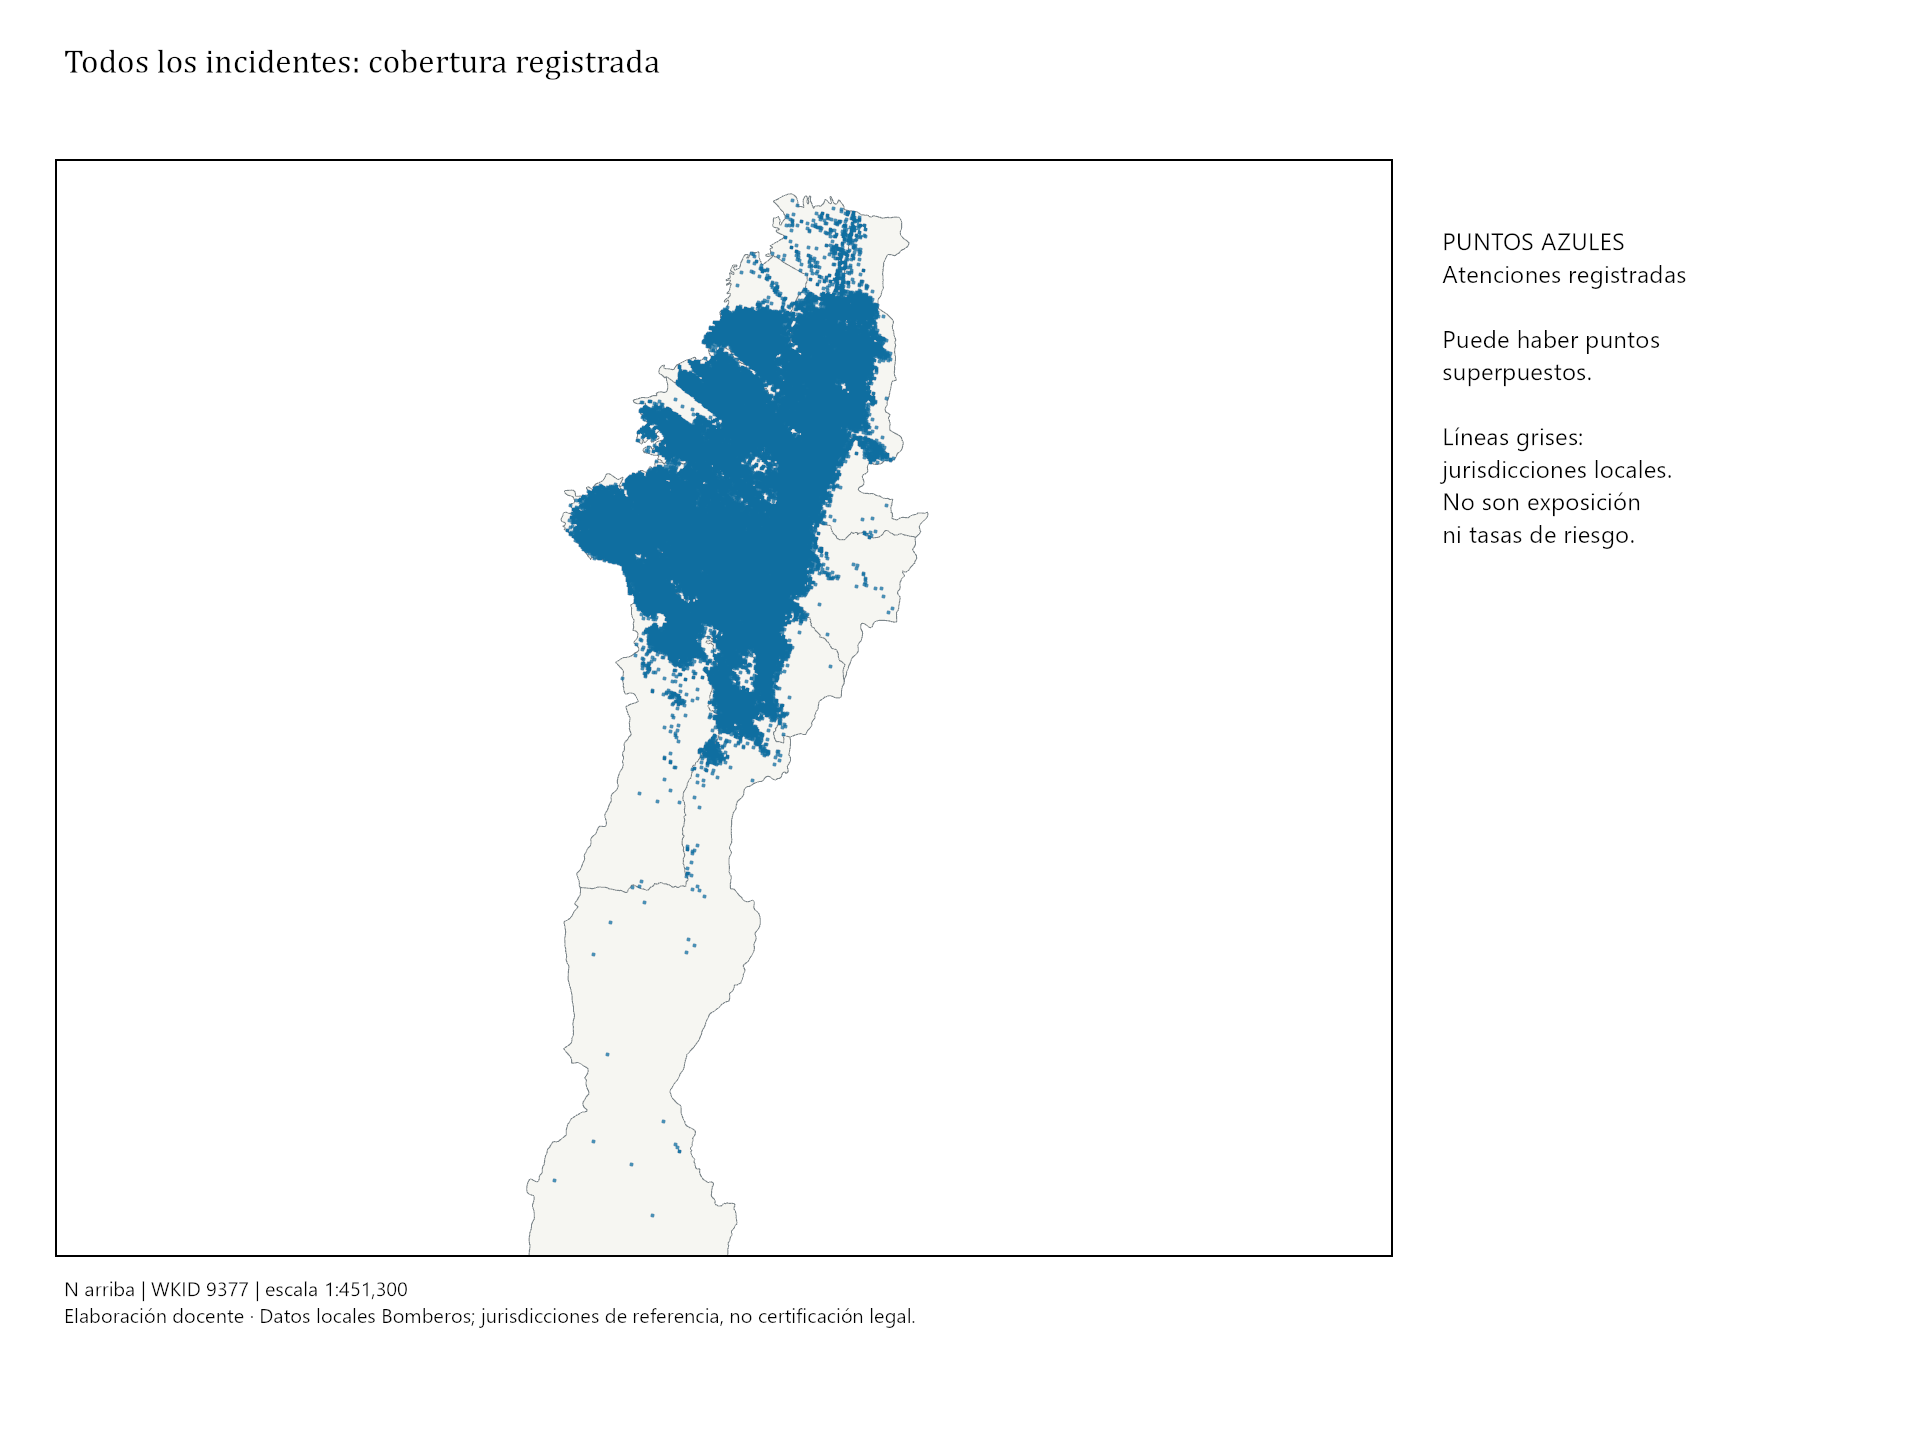

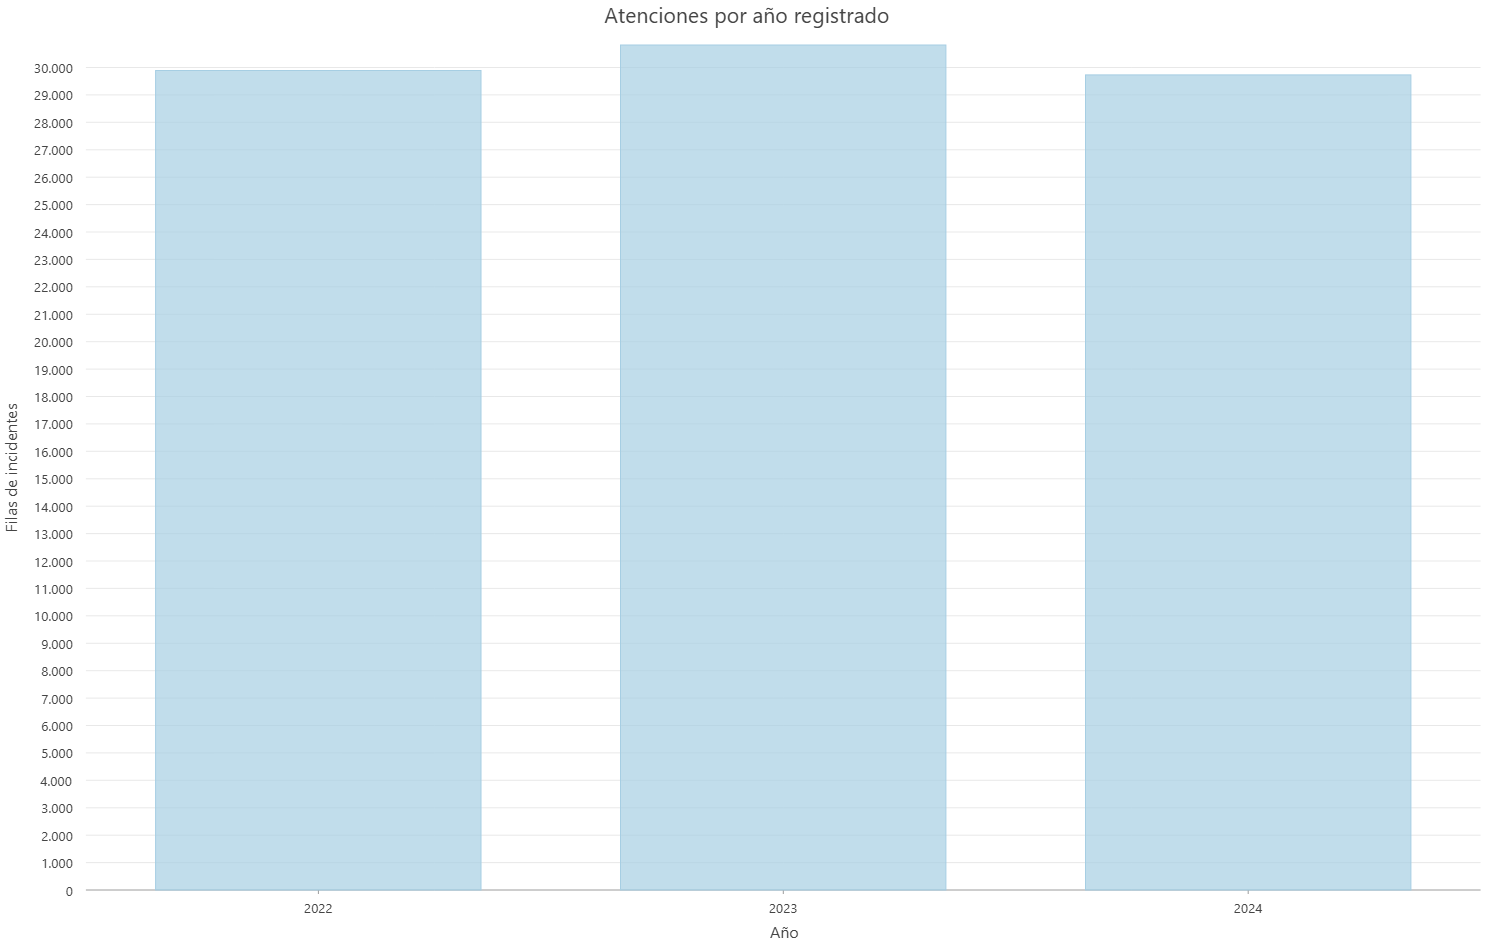

Servicio registrado,Filas
,10
1. INCENDIOS,5016
10. FALLA ELÉCTRICA,1354
11. ATENCIÓN PREHOSPITALARIA - APH,3253
12. QUEMAS PROHIBIDAS,5960
13. INCIDENTES CON ANIMALES,12672
15. INCIDENTE EMERGENCIA EN POTENCIA,3509
16. SERVICIO FUERA D.C.,13
17. ESPECIALES,15
19. CONTINUACIÓN,127


In [7]:
# ¿Dónde están las atenciones y qué años cubren?
point_map(incidents, 'eda_incidentes', 'Todos los incidentes: cobertura registrada')
year_table = frequency_table('eda_anios', [(str(k),v) for k,v in sorted(years.items())])
chart_png(arcpy.charts.Bar(x='Categoria', y='Cantidad', aggregation='SUM', dataSource=year_table,
    title='Atenciones por año registrado', xTitle='Año', yTitle='Filas de incidentes'), 'eda_anios')
table(['Servicio registrado', 'Filas'], sorted(counts[service].items(), key=lambda x: str(x[0])))


**Lectura de las barras:** 29 890 registros en 2022, 30 821 en 2023 y 29 732 en 2024. El punto del eje vertical separa miles. La entrada no es exclusivamente de 2024.

Las barras cuentan filas por año y el mapa muestra cobertura. Sin población expuesta, no son tasas de riesgo.

## ¿Qué cambia al seleccionar abejas?
El video (16/09/2026, **43:53–44:04**) selecciona exactamente `13.1 CONTROL ATAQUE MASIVO DE ABEJAS` en `IncidentesBomberos_CLASE_DE_S`. Comparar con esa etiqueta excluye nulos; no los convierte en «sin abejas». Mostramos consulta, conteos y mapa **antes de clustering**.

SQL: IncidentesBomberos_CLASE_DE_S = '13.1 CONTROL ATAQUE MASIVO DE ABEJAS'


Antes: 90443 | seleccionadas: 2173 | excluidas: 88270
Categorías nulas excluidas: 60711 | otras categorías: 27559


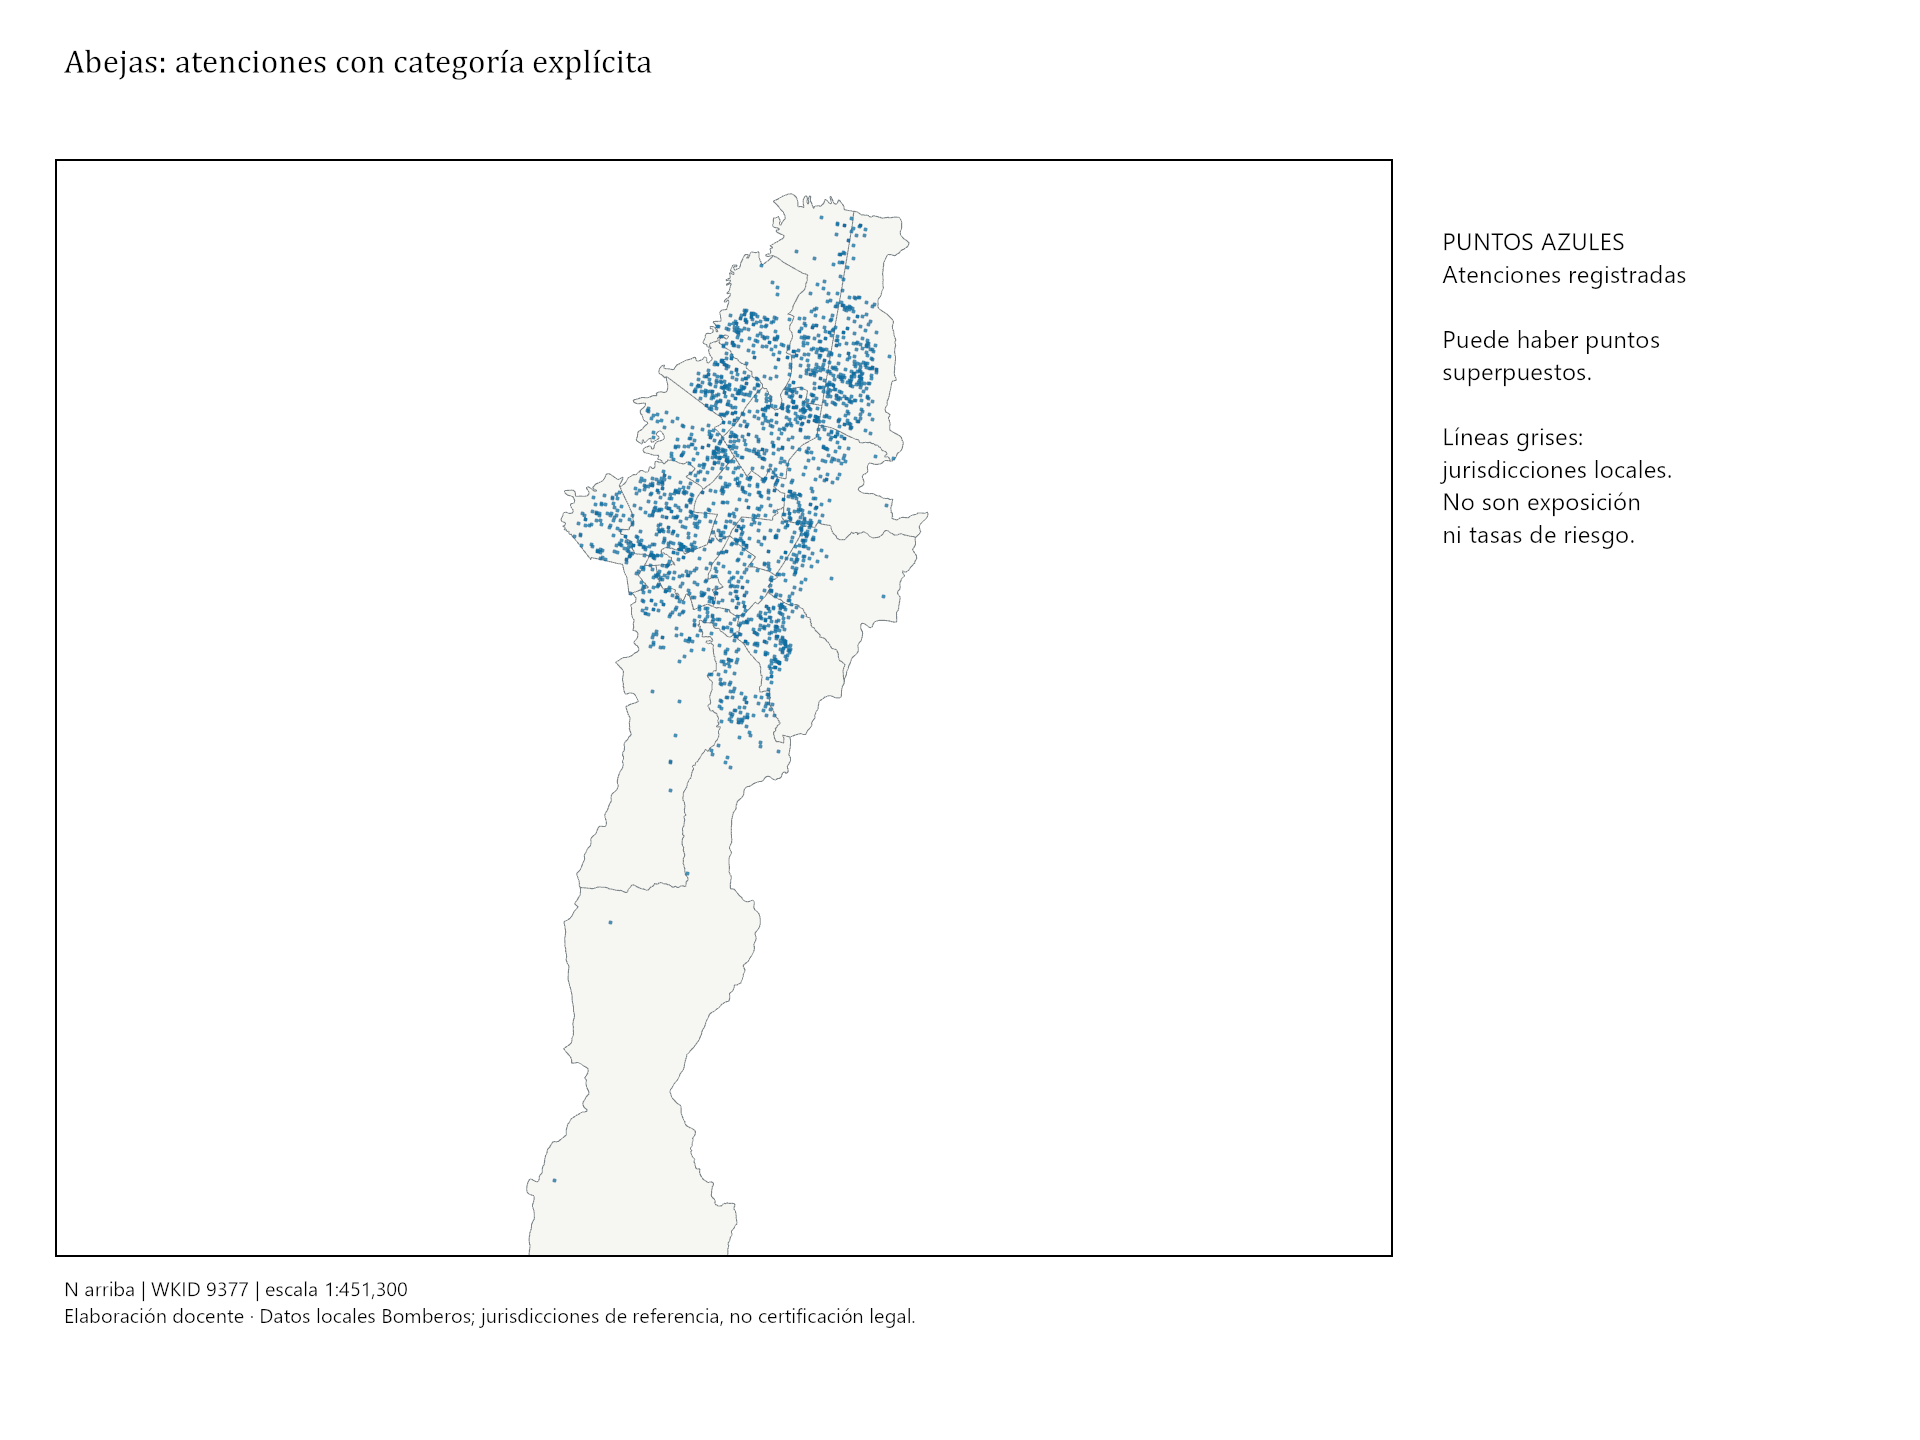

In [8]:
# Copia temática intacta para clustering y puntos calientes.
bee_value = '13.1 CONTROL ATAQUE MASIVO DE ABEJAS'
where = arcpy.AddFieldDelimiters(incidents, category) + " = '" + bee_value + "'"
print('SQL:', where)
selection = arcpy.management.MakeFeatureLayer(incidents, 'seleccion_abejas_' + run.name, where).getOutput(0)
bees = str(Path(gdb) / 'Abejas')
arcpy.management.CopyFeatures(selection, bees)
n_bees = int(arcpy.management.GetCount(bees)[0])
print('Antes:', n, '| seleccionadas:', n_bees, '| excluidas:', n-n_bees)
print('Categorías nulas excluidas:', counts[category][None], '| otras categorías:', n-n_bees-counts[category][None])
assert n_bees == counts[category][bee_value] and n_bees > 0
point_map(bees, 'abejas_seleccion', 'Abejas: atenciones con categoría explícita')


Esperamos 2 173 de 90 443 filas, con 60 711 categorías nulas en esta entrada; contraste con la salida. Seleccionamos atenciones identificables como abejas, no todas las emergencias ecológicas posibles.

## ¿Cien atenciones próximas forman un grupo?
**DBSCAN** busca zonas densas usando un mínimo de puntos y una distancia de vecindad. Aquí son **100 y 350 m**: 350 m no es el diámetro máximo de un grupo. **Ruido (-1)** significa que un punto no queda asignado bajo esa configuración, no que sea un error.

Primero usamos **solo abejas**, como el video en **55:30–55:36 y 58:00–58:04**, donde todos quedaron como ruido. Conservaremos el resultado local aunque difiera. [Esri, Density-based Clustering, Pro 3.6, Usage/Parameters](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/densitybasedclustering.htm).

Start Time: jueves, 17 de septiembre de 2026 1:12:30 p. m.
WARNING 110142: No clusters detected.
Succeeded at jueves, 17 de septiembre de 2026 1:12:33 p. m. (Elapsed Time: 3.65 seconds)


Configuración,Universo,Filas,Grupos,Ruido
DBSCAN 100 / 350 m,Abejas,2173,0,2173


Ruido no es error; las etiquetas solo identifican grupos de esta corrida.


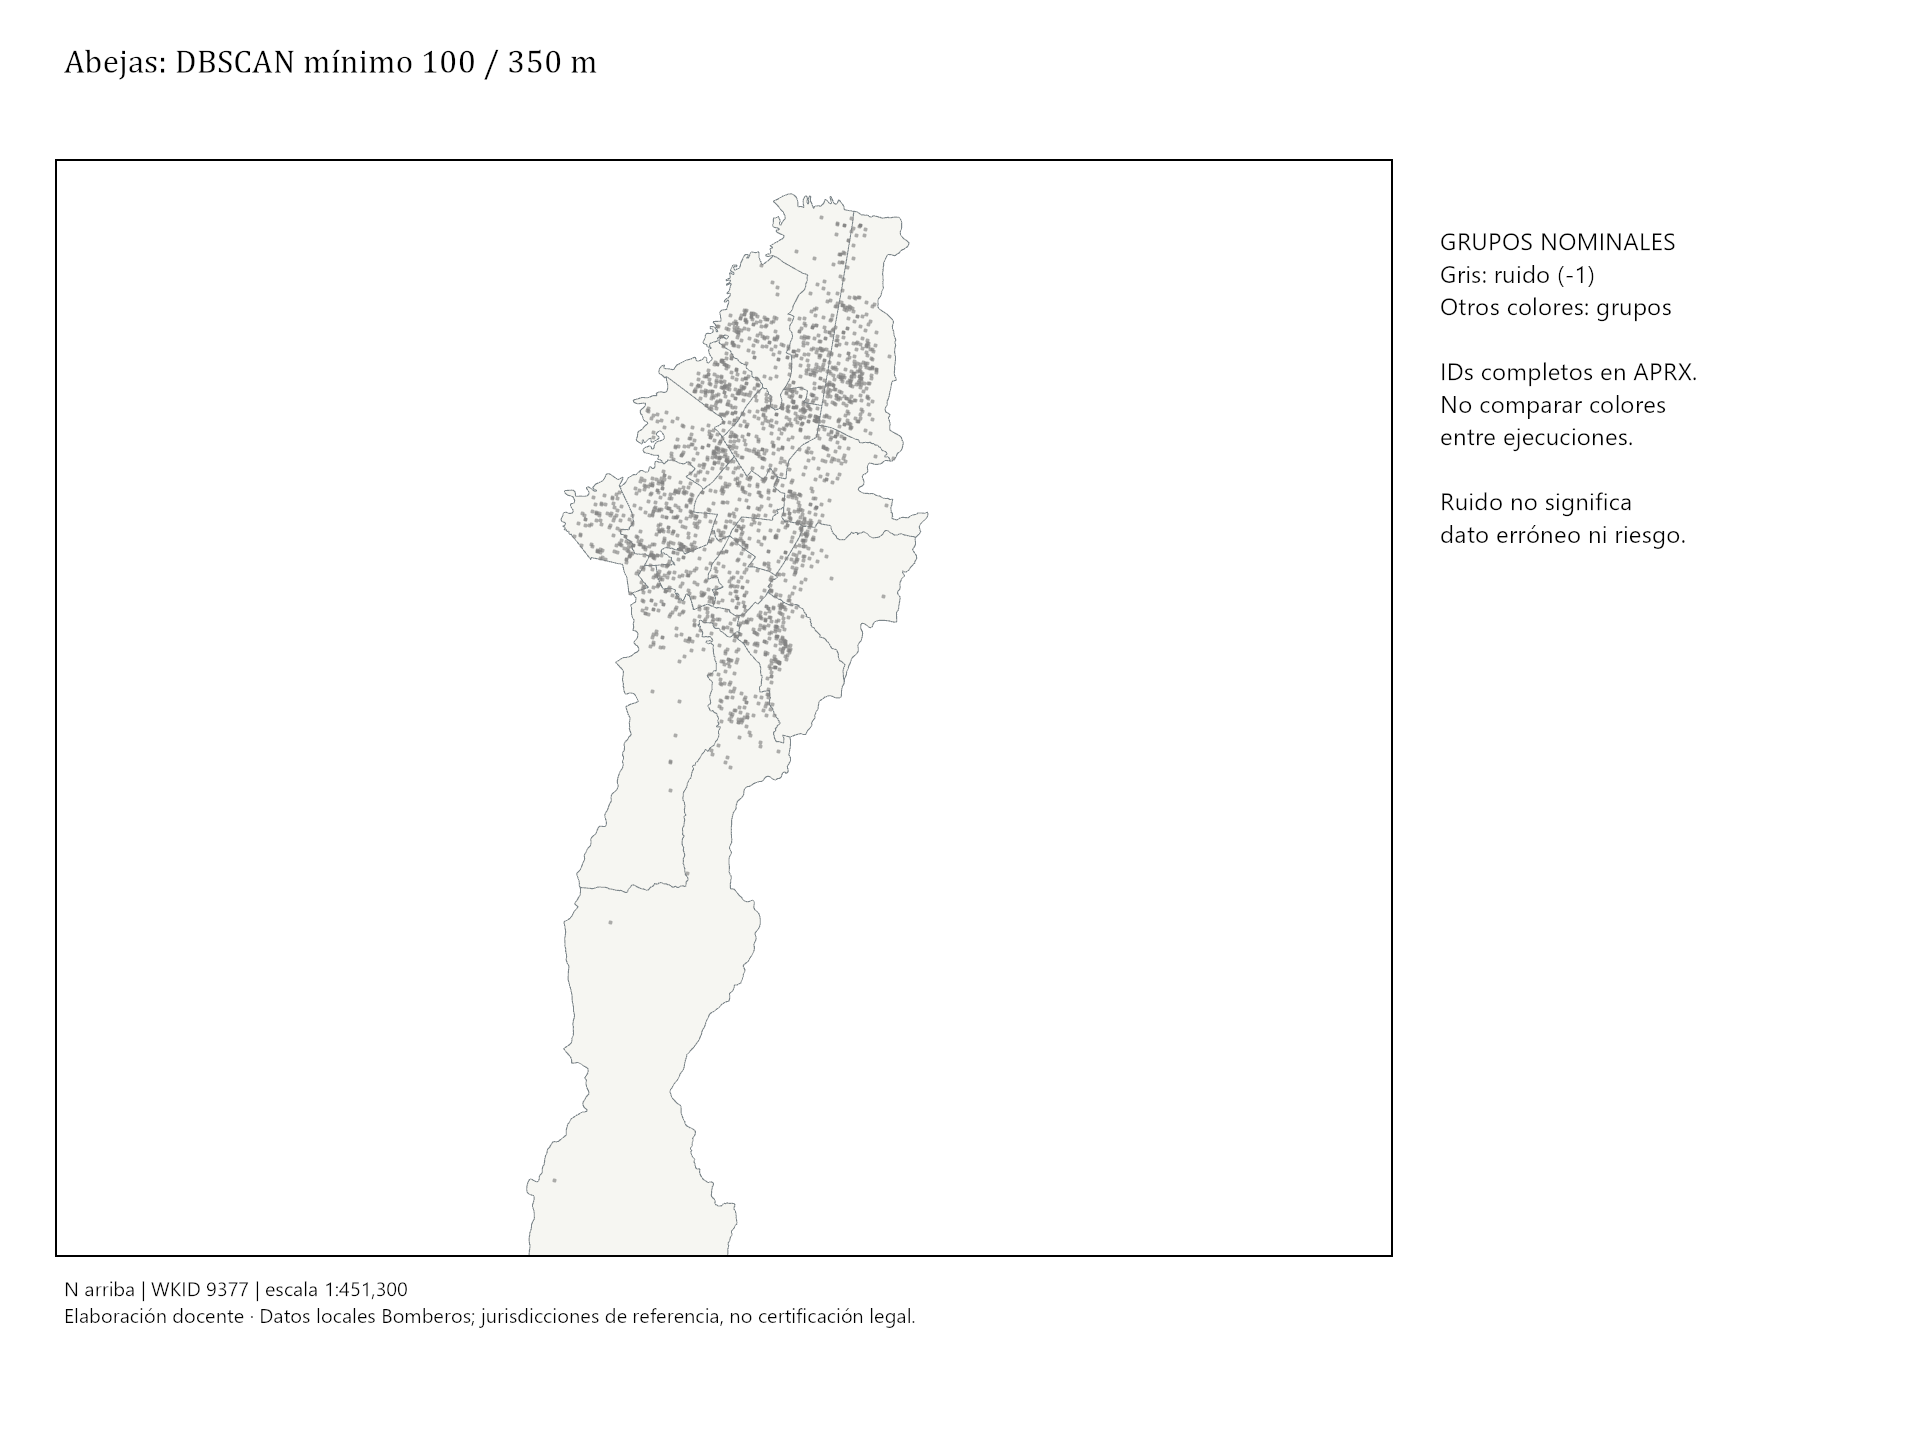

In [9]:
# Resumir etiquetas y guardar los mensajes de cada operación sin ocultar avisos.
cluster_summaries = []
def messages(result, name):
    text = result.getMessages()
    print(text)
    (run / (name + '_mensajes.txt')).write_text(text, encoding='utf-8')

def cluster_summary(fc, name, universe):
    with arcpy.da.SearchCursor(fc, ['CLUSTER_ID']) as cursor:
        labels = Counter(row[0] for row in cursor)
    row = [name, universe, sum(labels.values()), len([k for k in labels if k != -1]), labels[-1]]
    cluster_summaries.append(row)
    table(['Configuración', 'Universo', 'Filas', 'Grupos', 'Ruido'], [row])
    print('Ruido no es error; las etiquetas solo identifican grupos de esta corrida.')
    return labels

bee350 = str(Path(gdb) / 'DBSCAN_Abejas_100_350')
result = arcpy.stats.DensityBasedClustering(bees, bee350, 'DBSCAN', 100, '350 Meters')
messages(result, 'dbscan_abejas_350')
cluster_summary(bee350, 'DBSCAN 100 / 350 m', 'Abejas')
point_map(bee350, 'dbscan_abejas_350', 'Abejas: DBSCAN mínimo 100 / 350 m', cluster=True)


**Resultado local:** cero grupos y 2 173 puntos ruido; aparece WARNING 110142. El mapa gris reproduce el resultado de la fuente, no una falla que debamos corregir cambiando parámetros.

Si todo aparece gris, la configuración no encontró grupos suficientemente densos: no demuestra distribución aleatoria ni ausencia de abejas.

## Atención: ahora la fuente cambia a TODOS los incidentes
En **59:20–62:49** se usan todas las atenciones, aunque una capa de abejas pueda seguir visible. El insumo del geoprocesamiento, no la visibilidad de la capa, define la población.

Seguimos **DBSCAN 100/350 m → DBSCAN 50/100 m → HDBSCAN 100 → OPTICS 100/350 m automático**. HDBSCAN explora densidades variables; OPTICS ordena conexiones y permite leer su alcanzabilidad. En OPTICS dejamos sensibilidad vacía: automática no significa 100 ni un nivel de confianza. Las dos configuraciones DBSCAN cambian simultáneamente mínimo y distancia, por lo que no aíslan el efecto de un único parámetro.

Start Time: jueves, 17 de septiembre de 2026 1:12:37 p. m.
Number of Clusters 20
Noise features 13384
Succeeded at jueves, 17 de septiembre de 2026 1:12:48 p. m. (Elapsed Time: 11.06 seconds)


Configuración,Universo,Filas,Grupos,Ruido
Todos: DBSCAN 100 / 350 m,Todos,90443,20,13384


Ruido no es error; las etiquetas solo identifican grupos de esta corrida.


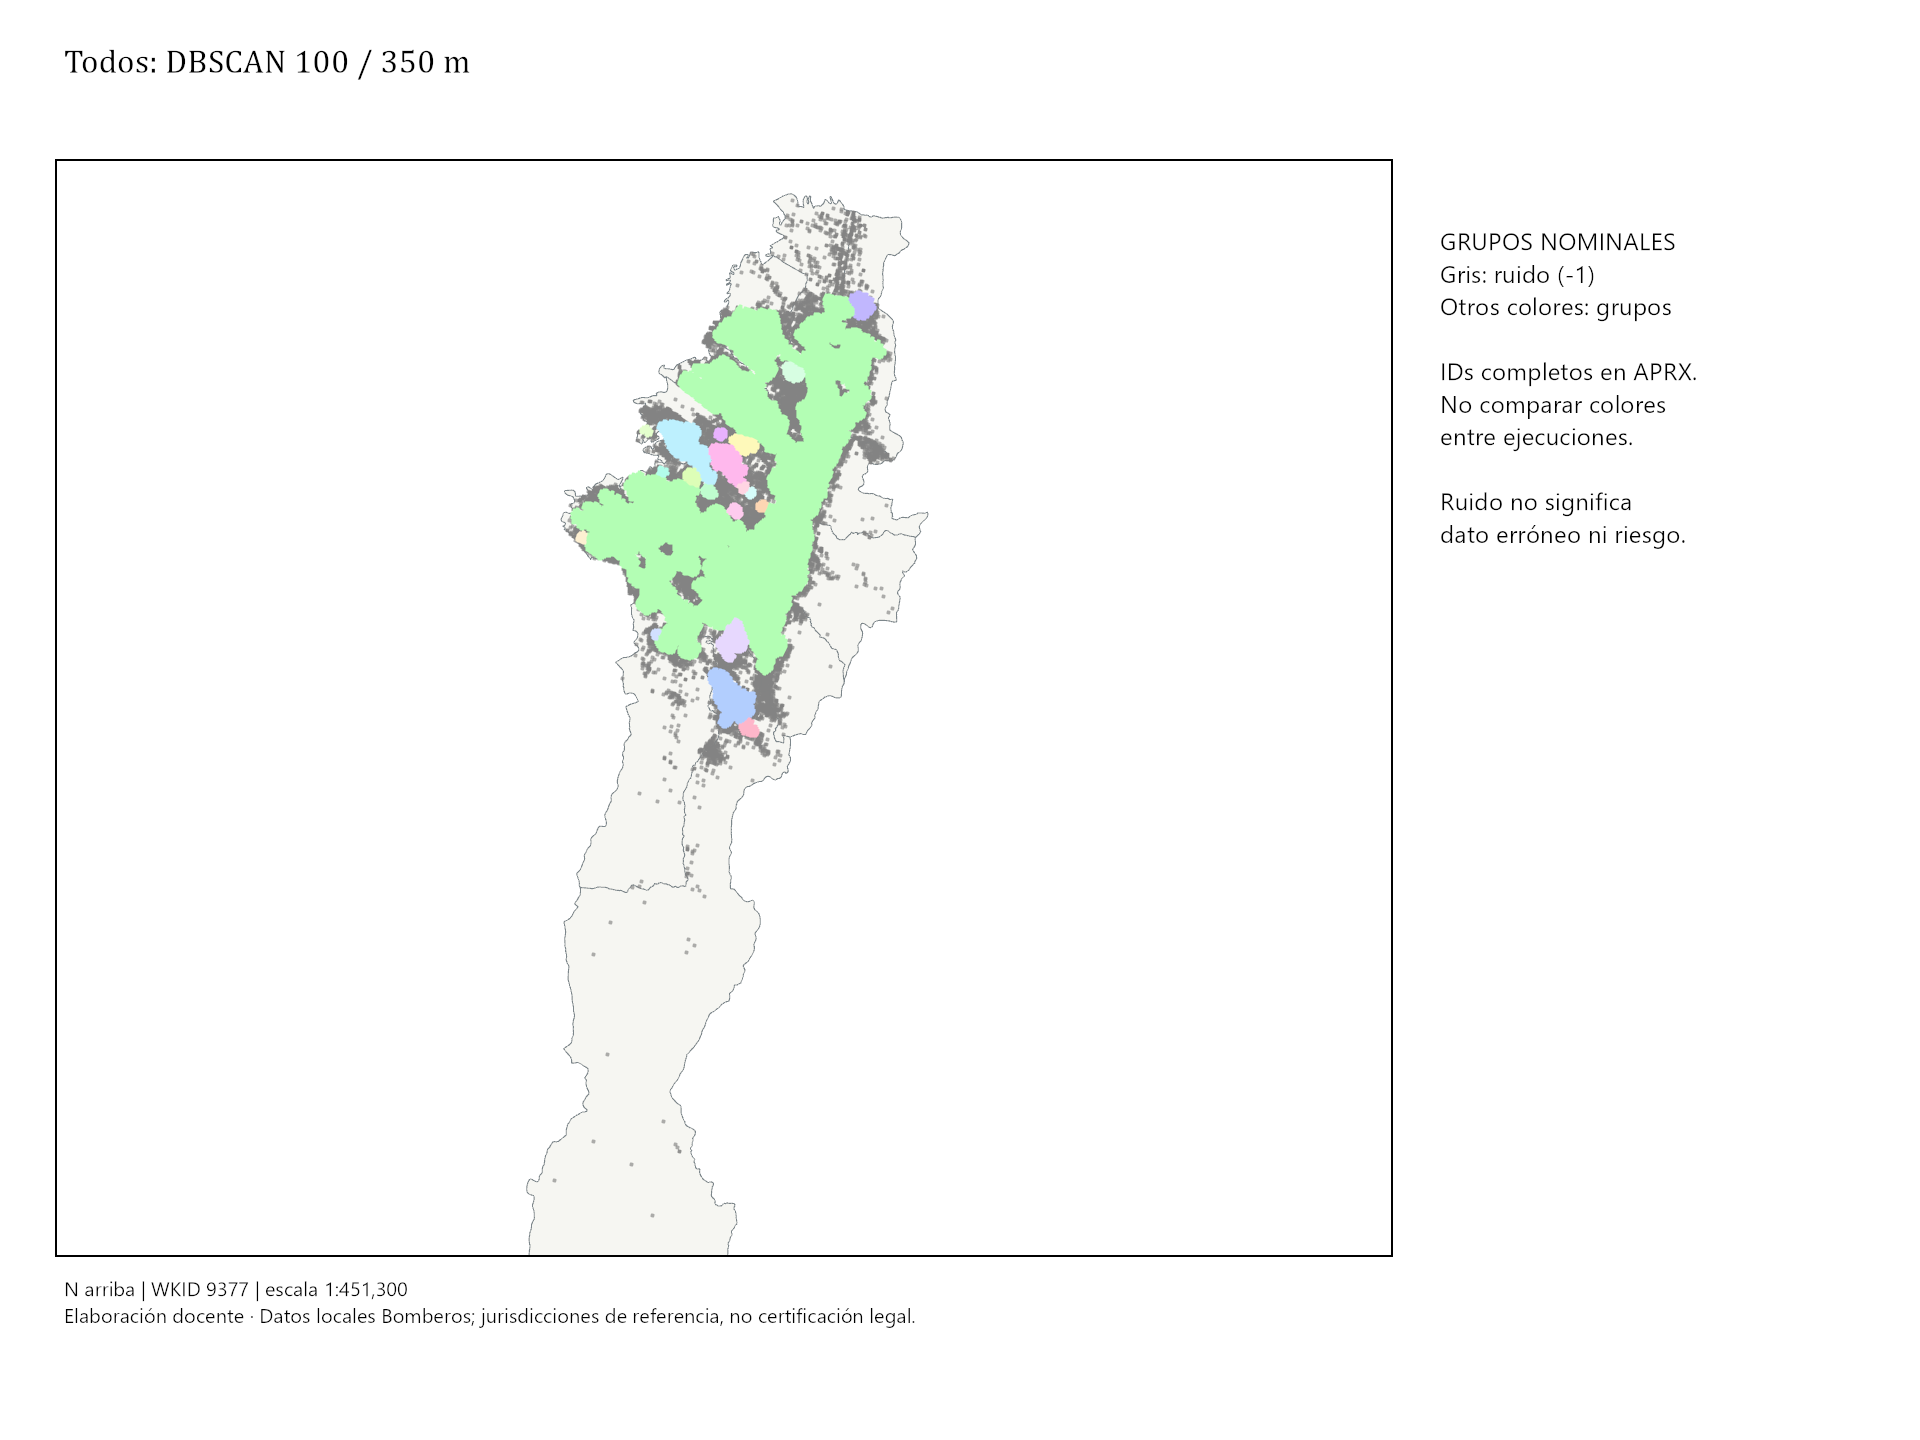

In [10]:
# Universo explícito: todos los incidentes; salida independiente.
output = str(Path(gdb) / 'DBSCAN_Todos_100_350')
result = arcpy.stats.DensityBasedClustering(incidents, output, 'DBSCAN', 100, '350 Meters')
messages(result, 'DBSCAN_Todos_100_350')
cluster_summary(output, 'Todos: DBSCAN 100 / 350 m', 'Todos')
point_map(output, 'DBSCAN_Todos_100_350', 'Todos: DBSCAN 100 / 350 m', cluster=True)


**Resultado local:** 20 grupos y 13 384 puntos ruido entre 90 443 incidentes.

Compare esta salida de todos con la de abejas solo para reconocer el cambio de población. Más puntos pueden satisfacer la densidad mínima donde el subconjunto no lo hacía; no significa que el método mejoró.

Start Time: jueves, 17 de septiembre de 2026 1:12:51 p. m.
Number of Clusters 5
Noise features 90087
Succeeded at jueves, 17 de septiembre de 2026 1:12:57 p. m. (Elapsed Time: 5.94 seconds)


Configuración,Universo,Filas,Grupos,Ruido
Todos: DBSCAN 50 / 100 m,Todos,90443,5,90087


Ruido no es error; las etiquetas solo identifican grupos de esta corrida.


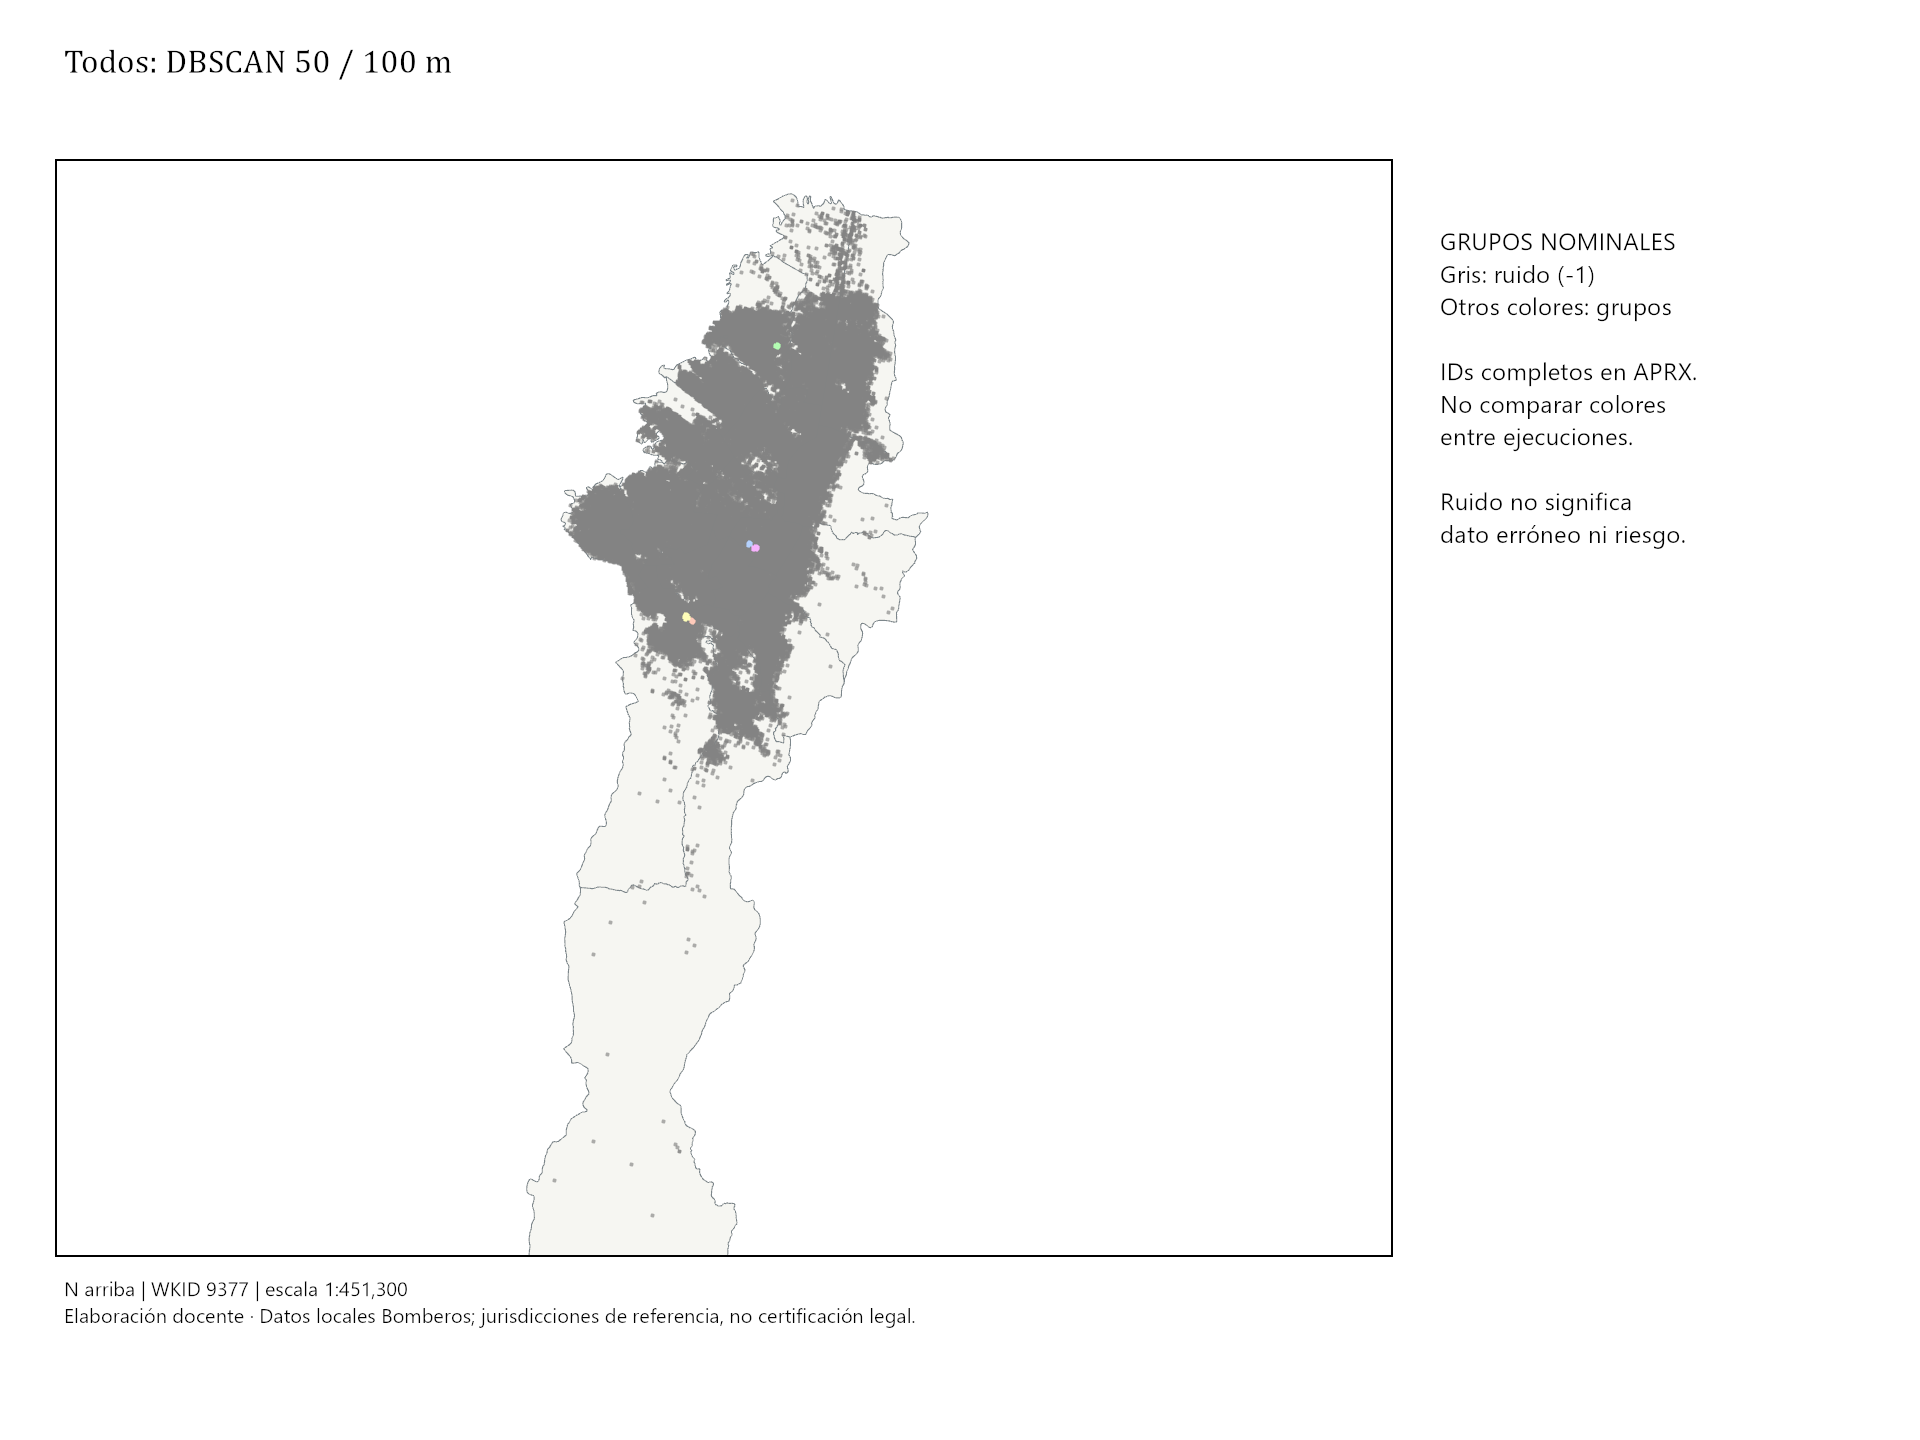

In [11]:
# Universo explícito: todos los incidentes; salida independiente.
output = str(Path(gdb) / 'DBSCAN_Todos_50_100')
result = arcpy.stats.DensityBasedClustering(incidents, output, 'DBSCAN', 50, '100 Meters')
messages(result, 'DBSCAN_Todos_50_100')
cluster_summary(output, 'Todos: DBSCAN 50 / 100 m', 'Todos')
point_map(output, 'DBSCAN_Todos_50_100', 'Todos: DBSCAN 50 / 100 m', cluster=True)


**Resultado local:** 5 grupos y 90 087 puntos ruido; los 356 asignados pertenecen a esta configuración más localizada, no al subconjunto de abejas.

Ahora el mínimo baja a 50 y el radio a 100 m: una exigencia se relaja y otra se restringe. El número de grupos no tiene por qué cambiar monótonamente. Compare recuentos, no etiquetas.

Start Time: jueves, 17 de septiembre de 2026 1:13:00 p. m.
Number of Clusters 3
Noise features 1187
Succeeded at jueves, 17 de septiembre de 2026 1:13:41 p. m. (Elapsed Time: 40.64 seconds)


Configuración,Universo,Filas,Grupos,Ruido
Todos: HDBSCAN mínimo 100,Todos,90443,3,1187


Ruido no es error; las etiquetas solo identifican grupos de esta corrida.


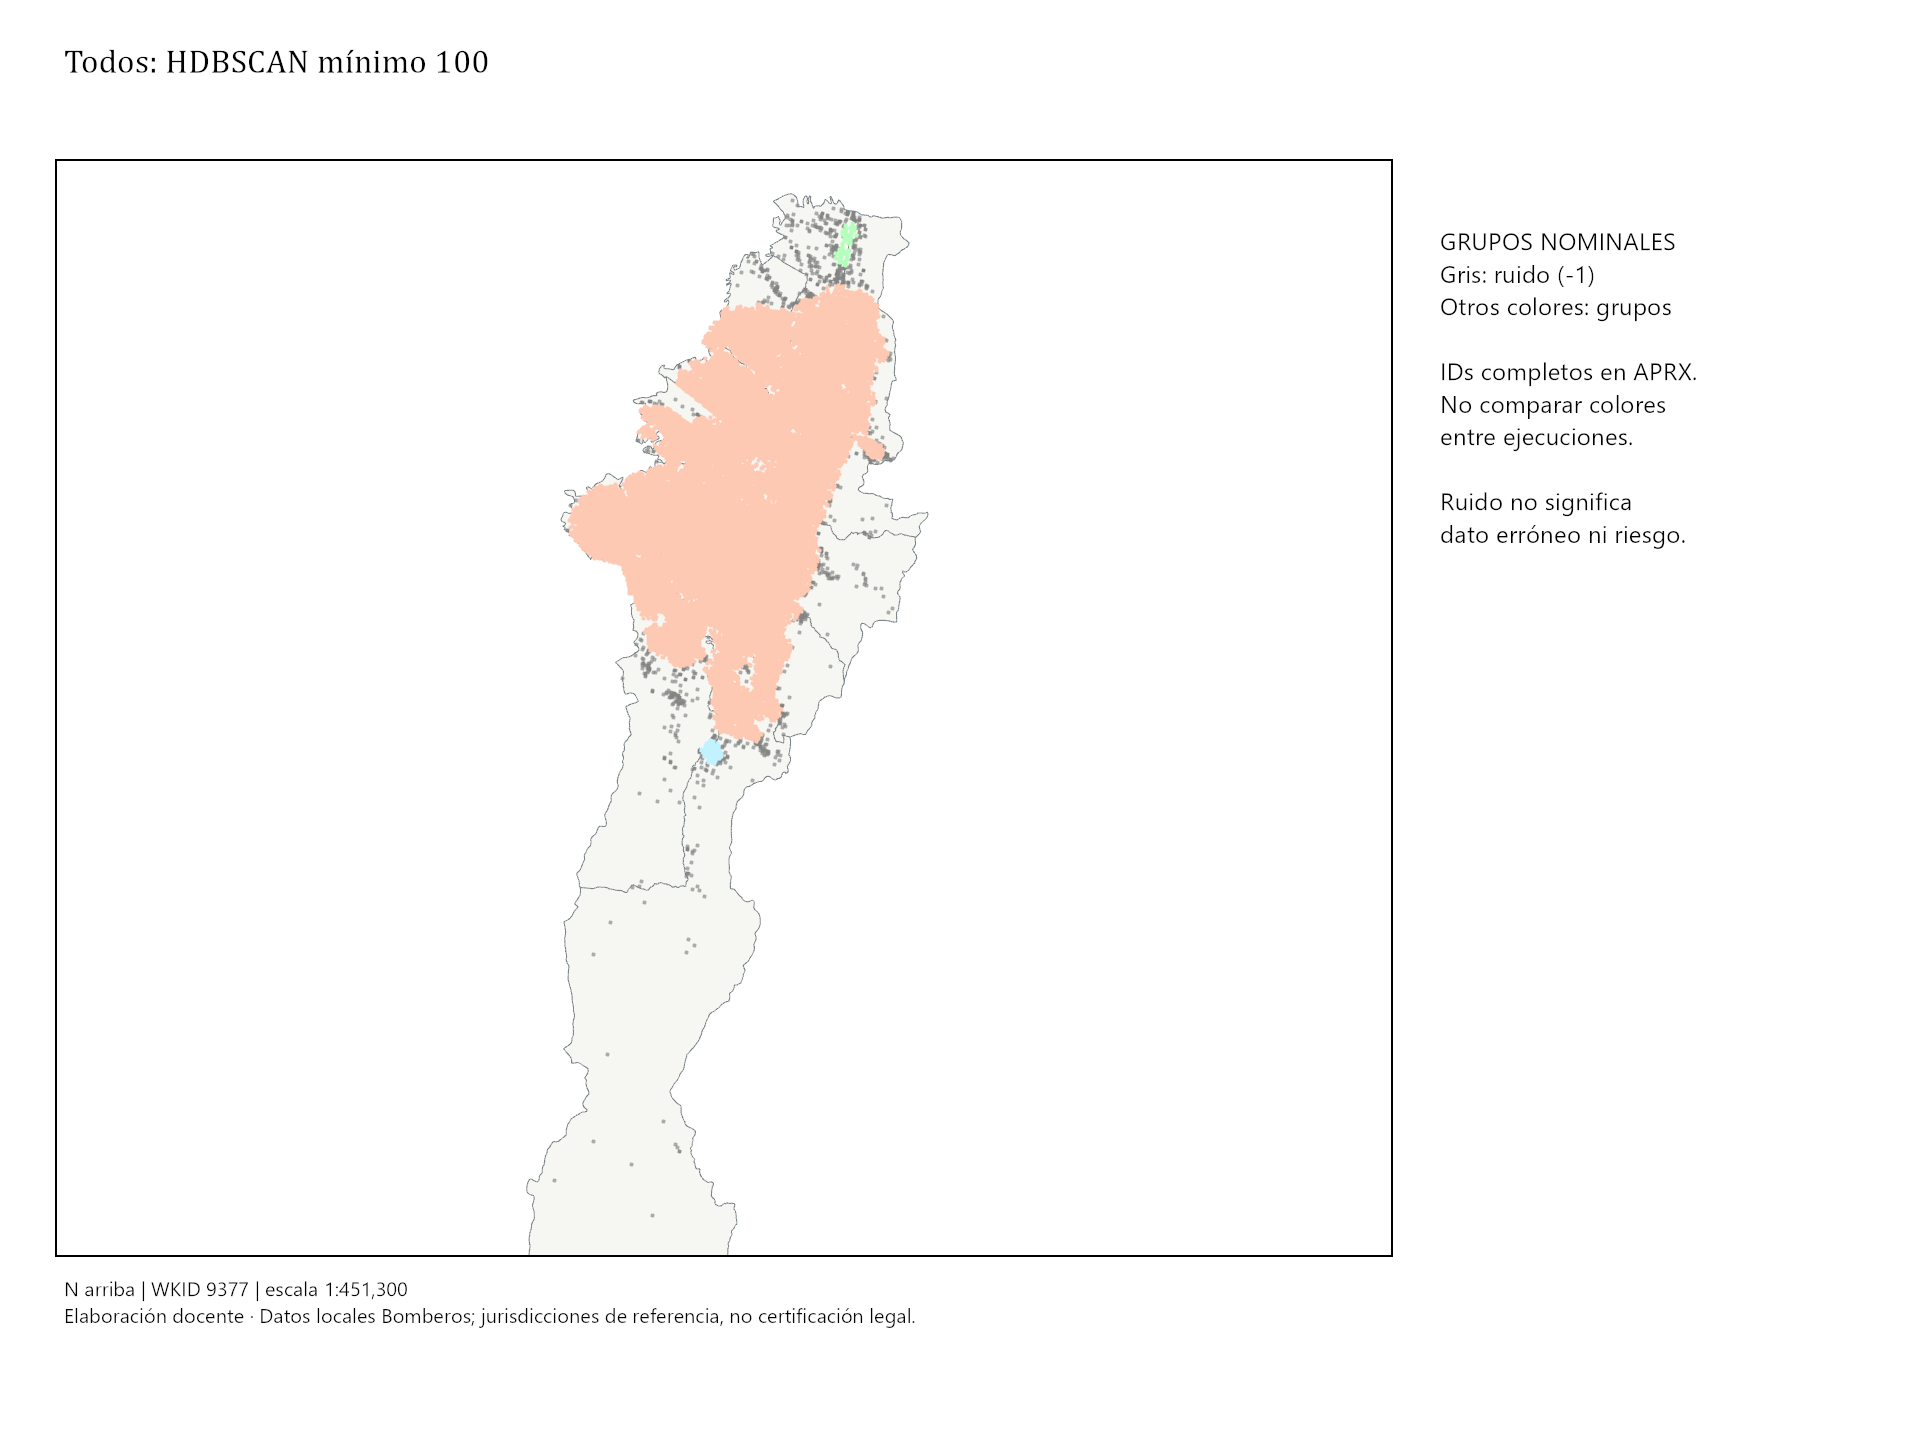

In [12]:
# Universo explícito: todos los incidentes; salida independiente.
output = str(Path(gdb) / 'HDBSCAN_Todos_100')
result = arcpy.stats.DensityBasedClustering(incidents, output, 'HDBSCAN', 100)
messages(result, 'HDBSCAN_Todos_100')
cluster_summary(output, 'Todos: HDBSCAN mínimo 100', 'Todos')
point_map(output, 'HDBSCAN_Todos_100', 'Todos: HDBSCAN mínimo 100', cluster=True)


**Resultado local:** 3 grupos y 1 187 puntos ruido. El gran grupo dominante no representa una zona homogénea de riesgo.

HDBSCAN explora densidades variables; mínimo 100 no impone el radio fijo de DBSCAN. Color significa pertenencia, no intensidad.

Start Time: jueves, 17 de septiembre de 2026 1:13:45 p. m.
Cluster sensitivity used 1
Second best sensitivity 0
Number of Clusters 29
Noise features 17561
Succeeded at jueves, 17 de septiembre de 2026 1:14:08 p. m. (Elapsed Time: 23.74 seconds)


Configuración,Universo,Filas,Grupos,Ruido
Todos: OPTICS 100 / 350 m automático,Todos,90443,29,17561


Ruido no es error; las etiquetas solo identifican grupos de esta corrida.


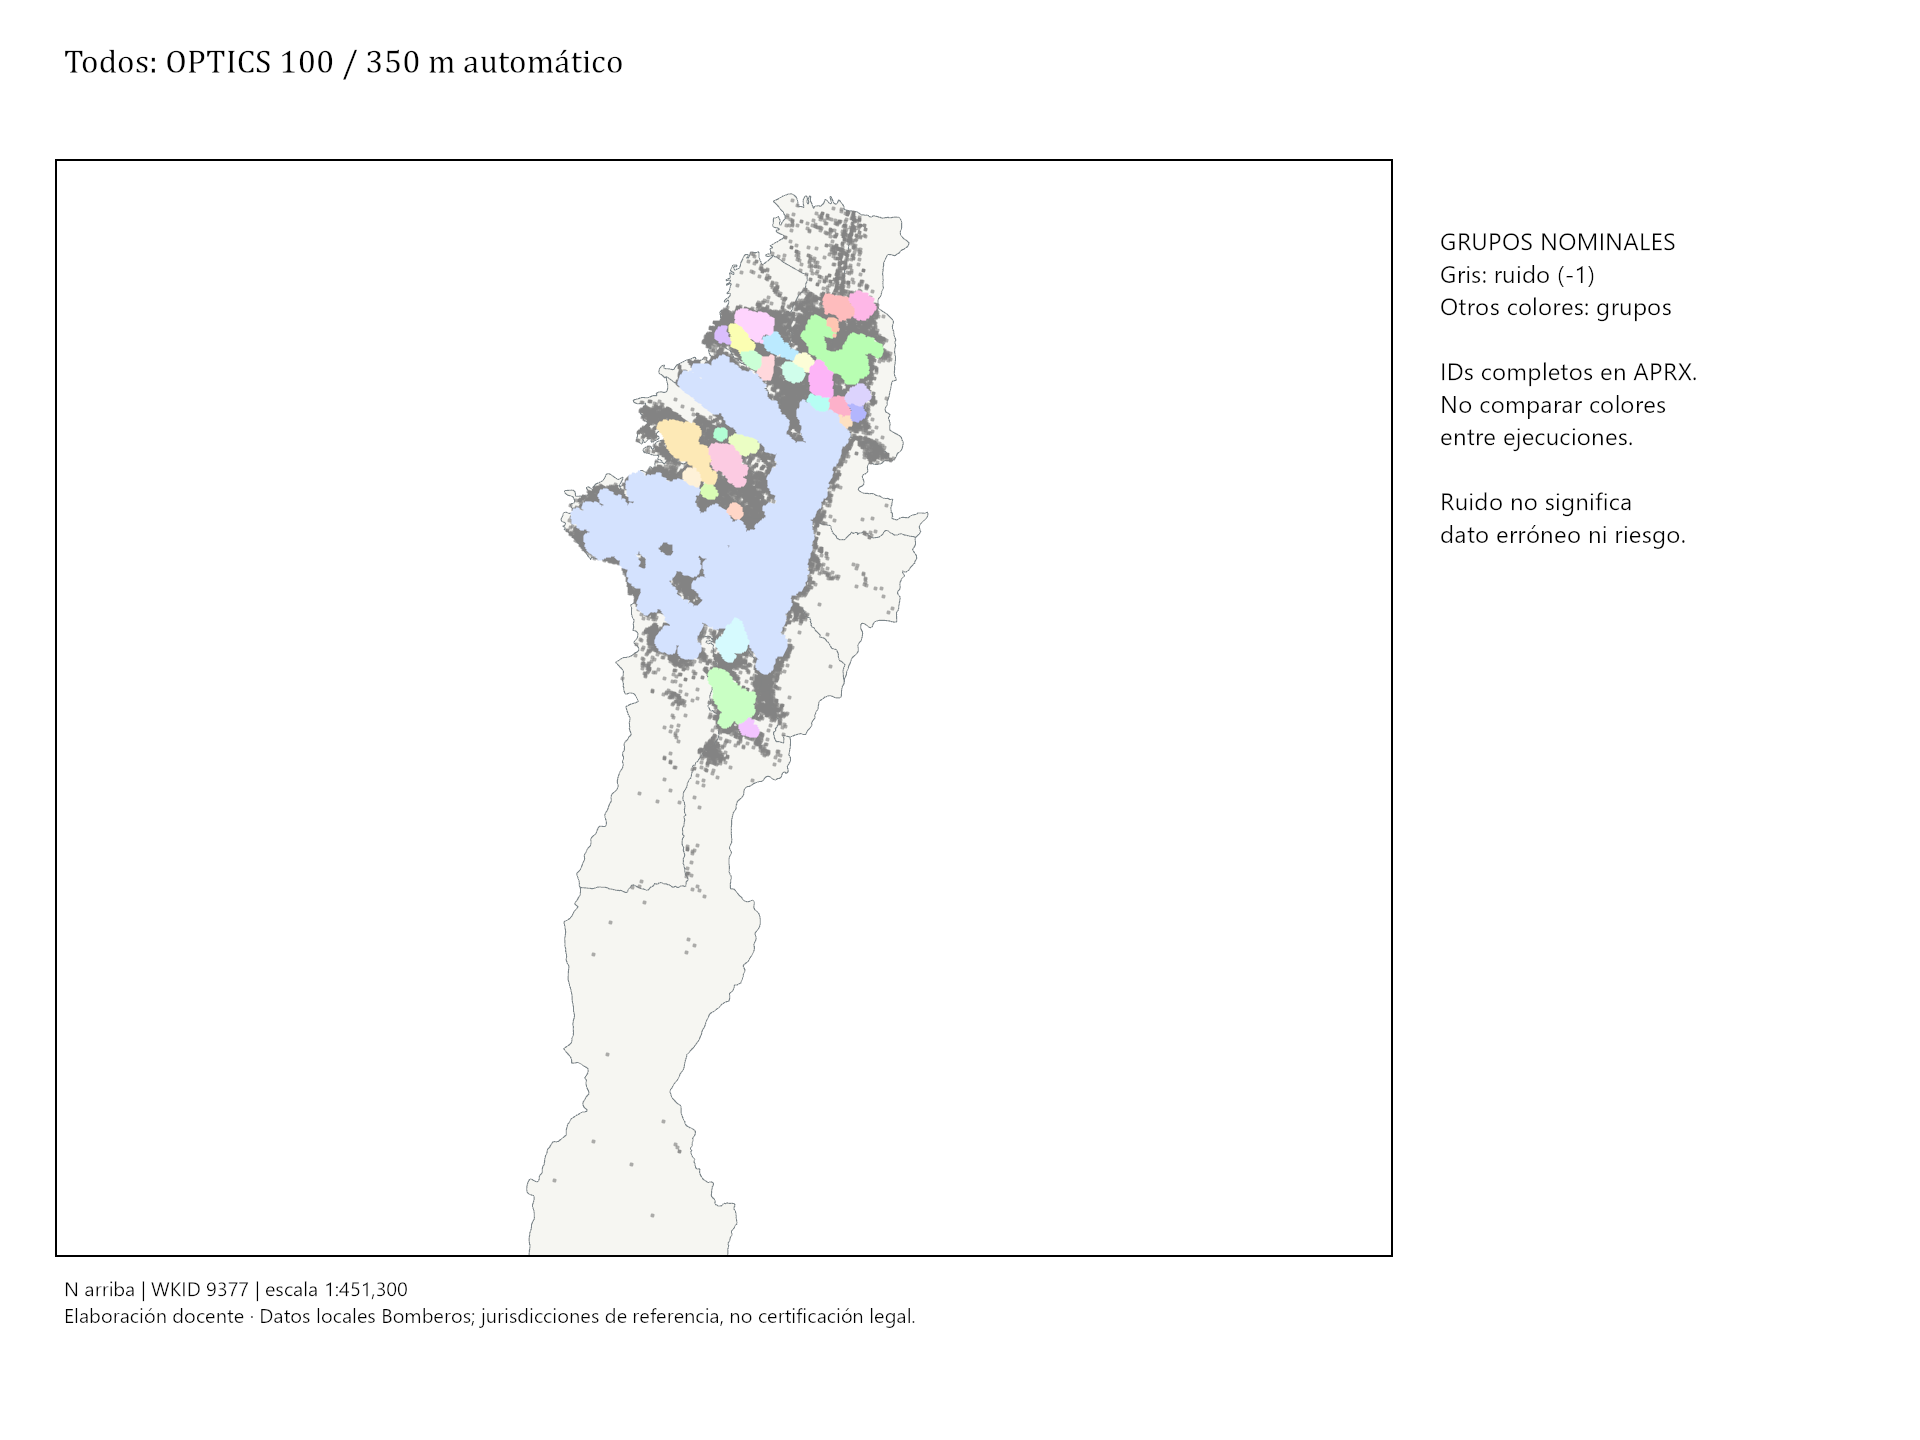

In [13]:
# Universo explícito: todos los incidentes; salida independiente.
output = str(Path(gdb) / 'OPTICS_Todos_100_350')
result = arcpy.stats.DensityBasedClustering(incidents, output, 'OPTICS', 100, '350 Meters')
messages(result, 'OPTICS_Todos_100_350')
cluster_summary(output, 'Todos: OPTICS 100 / 350 m automático', 'Todos')
point_map(output, 'OPTICS_Todos_100_350', 'Todos: OPTICS 100 / 350 m automático', cluster=True)


**Resultado local:** sensibilidad automática 1, 29 grupos y 17 561 puntos ruido. No se ejecutó una variante de sensibilidad 100.

OPTICS conserva un recorrido y alcanzabilidad. Lea la sensibilidad automática elegida en los mensajes antes de comparar métodos.

### Leer el recorrido de OPTICS
`REACHORDER` es orden de recorrido, no fecha ni OID. `REACHDIST` es alcanzabilidad en metros: los valles sugieren conexiones relativamente cortas. Un salto no identifica por sí mismo una barrera urbana. No definimos distancias desconocidas como cero; las contamos y omitimos solo del gráfico.

Alcanzabilidades no representables: 0


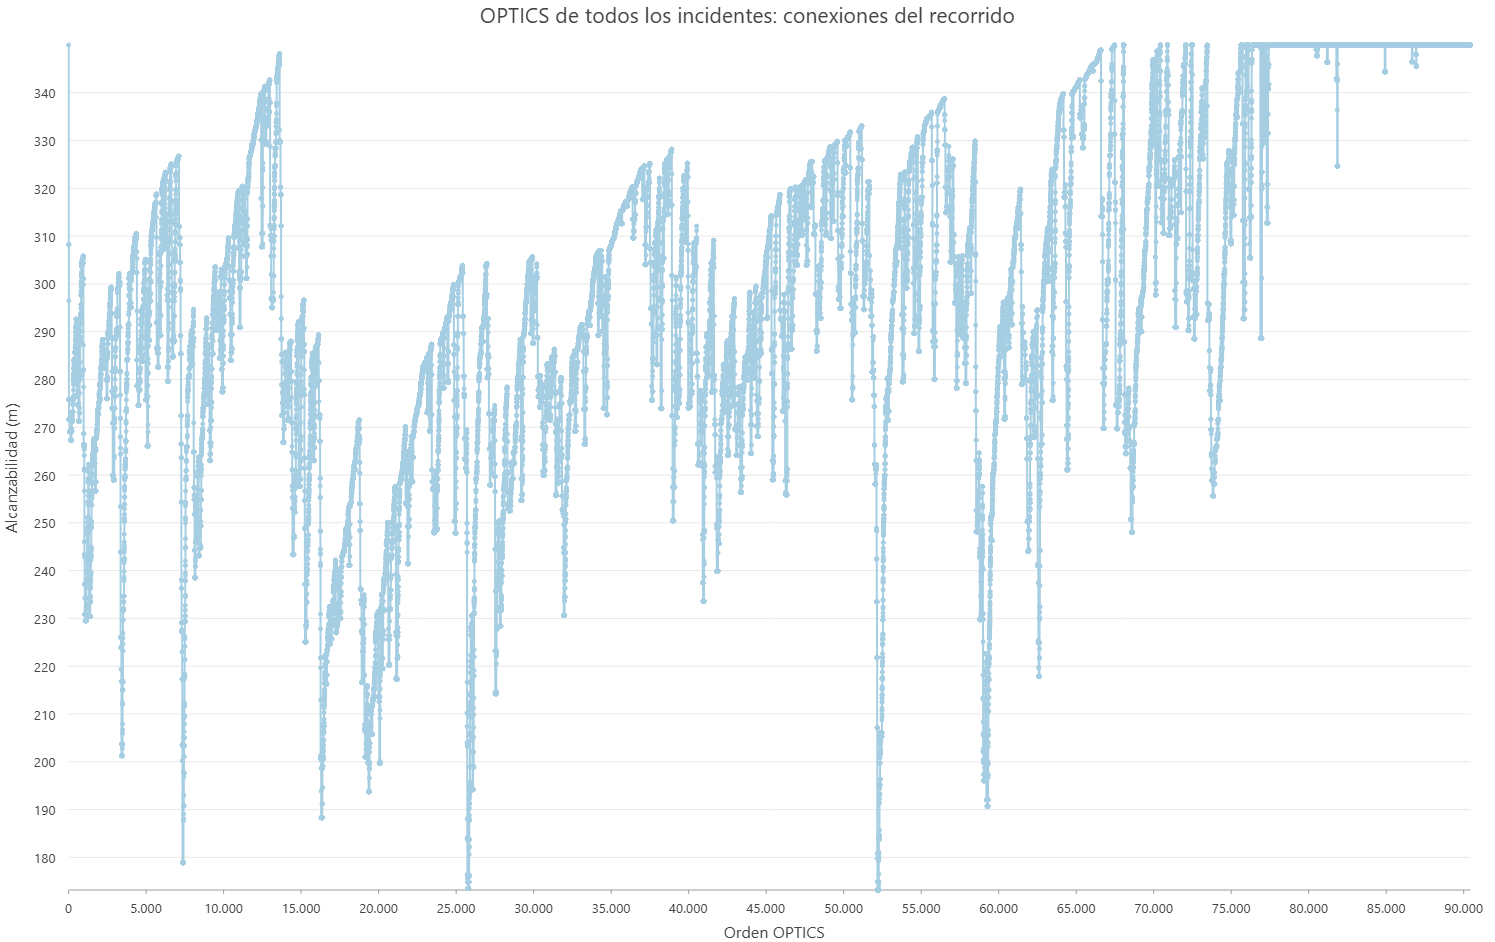

In [14]:
# El perfil usa la salida OPTICS anterior y conserva todos los puntos del modelo.
with arcpy.da.SearchCursor(output, ['REACHORDER', 'REACHDIST']) as cursor:
    reach = sorted(list(cursor), key=lambda row: row[0])
valid_reach = [(order, value) for order,value in reach if value is not None and math.isfinite(value) and value >= 0]
print('Alcanzabilidades no representables:', len(reach)-len(valid_reach))
profile = frequency_table('optics_alcanzabilidad', valid_reach, ('Orden', 'Alcanzabilidad'))
chart_png(arcpy.charts.Line(x='Orden', y='Alcanzabilidad', dataSource=profile,
    title='OPTICS de todos los incidentes: conexiones del recorrido', xTitle='Orden OPTICS', yTitle='Alcanzabilidad (m)'), 'optics_perfil')


**Lectura del perfil:** no hubo alcanzabilidades no representables. El eje y está ampliado aproximadamente a 173–350 m; la meseta superior queda condicionada por la búsqueda de 350 m. No equivale a un límite urbano.

Los valles dependen de densidad, mínimo y búsqueda de 350 m. No son probabilidades ni distancias sobre la red vial.

## Volvemos a ABEJAS: ¿dónde se concentran conteos altos o bajos?
Un grupo de puntos y un punto caliente responden preguntas distintas. **Optimized Hot Spot Analysis (OHA)** cuenta incidentes en hexágonos y contrasta concentración local con Getis-Ord Gi*. Un conteo alto aislado no basta: importa también su vecindad.

Reproducimos **67:28–68:18**: `Analysis_Field` vacío, `COUNT_INCIDENTS_WITHIN_HEXAGON_POLYGONS`, polígonos delimitadores y tamaño de celda/distancia automáticos. Al dar polígonos donde los incidentes son posibles, se conservan celdas con **cero** incidentes: no son datos faltantes. El soporte deja de ser únicamente sitios ocupados.

[Esri, Optimized Hot Spot Analysis, Pro 3.6, Parameters/Python](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/optimized-hot-spot-analysis.htm) y [How Optimized Hot Spot Analysis works, agregación/escala](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/how-optimized-hot-spot-analysis-works.htm), consulta 2026-09-17.

In [15]:
# Dos delimitaciones explícitas: el código real usa B-10, no B10.
territory_sql = arcpy.AddFieldDelimiters(jurisdictions, 'ESTACION') + " <> 'B-10'"
without_b10 = arcpy.management.MakeFeatureLayer(jurisdictions, 'sin_B10_' + run.name, territory_sql).getOutput(0)
print('SQL territorial:', territory_sql)
print('Jurisdicciones completas:', arcpy.management.GetCount(jurisdictions)[0], '| sin B-10:', arcpy.management.GetCount(without_b10)[0])
with arcpy.da.SearchCursor(jurisdictions, ['ESTACION', 'NOMBRE_CORTO_EST']) as cursor:
    print('Identidad de B-10:', [(s, name.strip()) for s,name in cursor if s == 'B-10'])
# Primer análisis: abejas sin integrar, 17 polígonos, campo y escalas vacíos.
oha_all = str(Path(gdb) / 'OHA_Abejas_17')
result = arcpy.stats.OptimizedHotSpotAnalysis(bees, oha_all, '',
    'COUNT_INCIDENTS_WITHIN_HEXAGON_POLYGONS', jurisdictions)
messages(result, 'OHA_17')


SQL territorial: ESTACION <> 'B-10'
Jurisdicciones completas: 17 | sin B-10: 16
Identidad de B-10: [('B-10', 'Marichuela')]


Start Time: jueves, 17 de septiembre de 2026 1:14:22 p. m.

************************** Initial Data Assessment ***************************
Making sure there are enough incidents for analysis....
    - There are 2173 valid input features.

Looking for locational outliers....
    - There were 9 outlier locations; these will not be used to compute the hexagon size.

Evaluating the bounding polygon feature class....
    - The total study area is 1633370812.351 square meters.

**************************** Incident Aggregation ****************************
    - Using a hexagon of width 796.7434 meters and height 690.0000 meters

Counting the number of incidents in each hexagon....
    - Analysis is performed on all hexagons within the bounding polygon feature class.

Evaluating incident counts and number of polygons....
    - The aggregation process resulted in 4318 weighted polygons.
    - Incident Count Properties:
        Min:        0.0000
        Max:       15.0000
        Mean:       0

Los mensajes anteriores contienen celda, distancia y advertencias realmente elegidas por la herramienta. No fijamos una escala para obtener colores atractivos.

**Gi_Bin** clasifica con corrección FDR por múltiples contrastes locales: −3/−2/−1 son fríos a 99/95/90 %, 0 no significativo, +1/+2/+3 calientes a 90/95/99 %. Los porcentajes son niveles estadísticos, no porcentaje de incidentes ni probabilidad de riesgo. Los z y p crudos no incorporan esa corrección. No significación no prueba seguridad ni aleatoriedad.

En esta salida OHA el conteo se llama `JOIN_COUNT`; `ICOUNT` se reserva para los sitios de Collect Events más adelante. No son el mismo soporte.

Gi_Bin FDR,Clase,Hexágonos
-3,Frío 99%,0
-2,Frío 95%,0
-1,Frío 90%,2329
0,No significativo,1055
1,Caliente 90%,74
2,Caliente 95%,47
3,Caliente 99%,813


Hexágonos: 4318 | ceros: 3534 | suma JOIN_COUNT: 2173


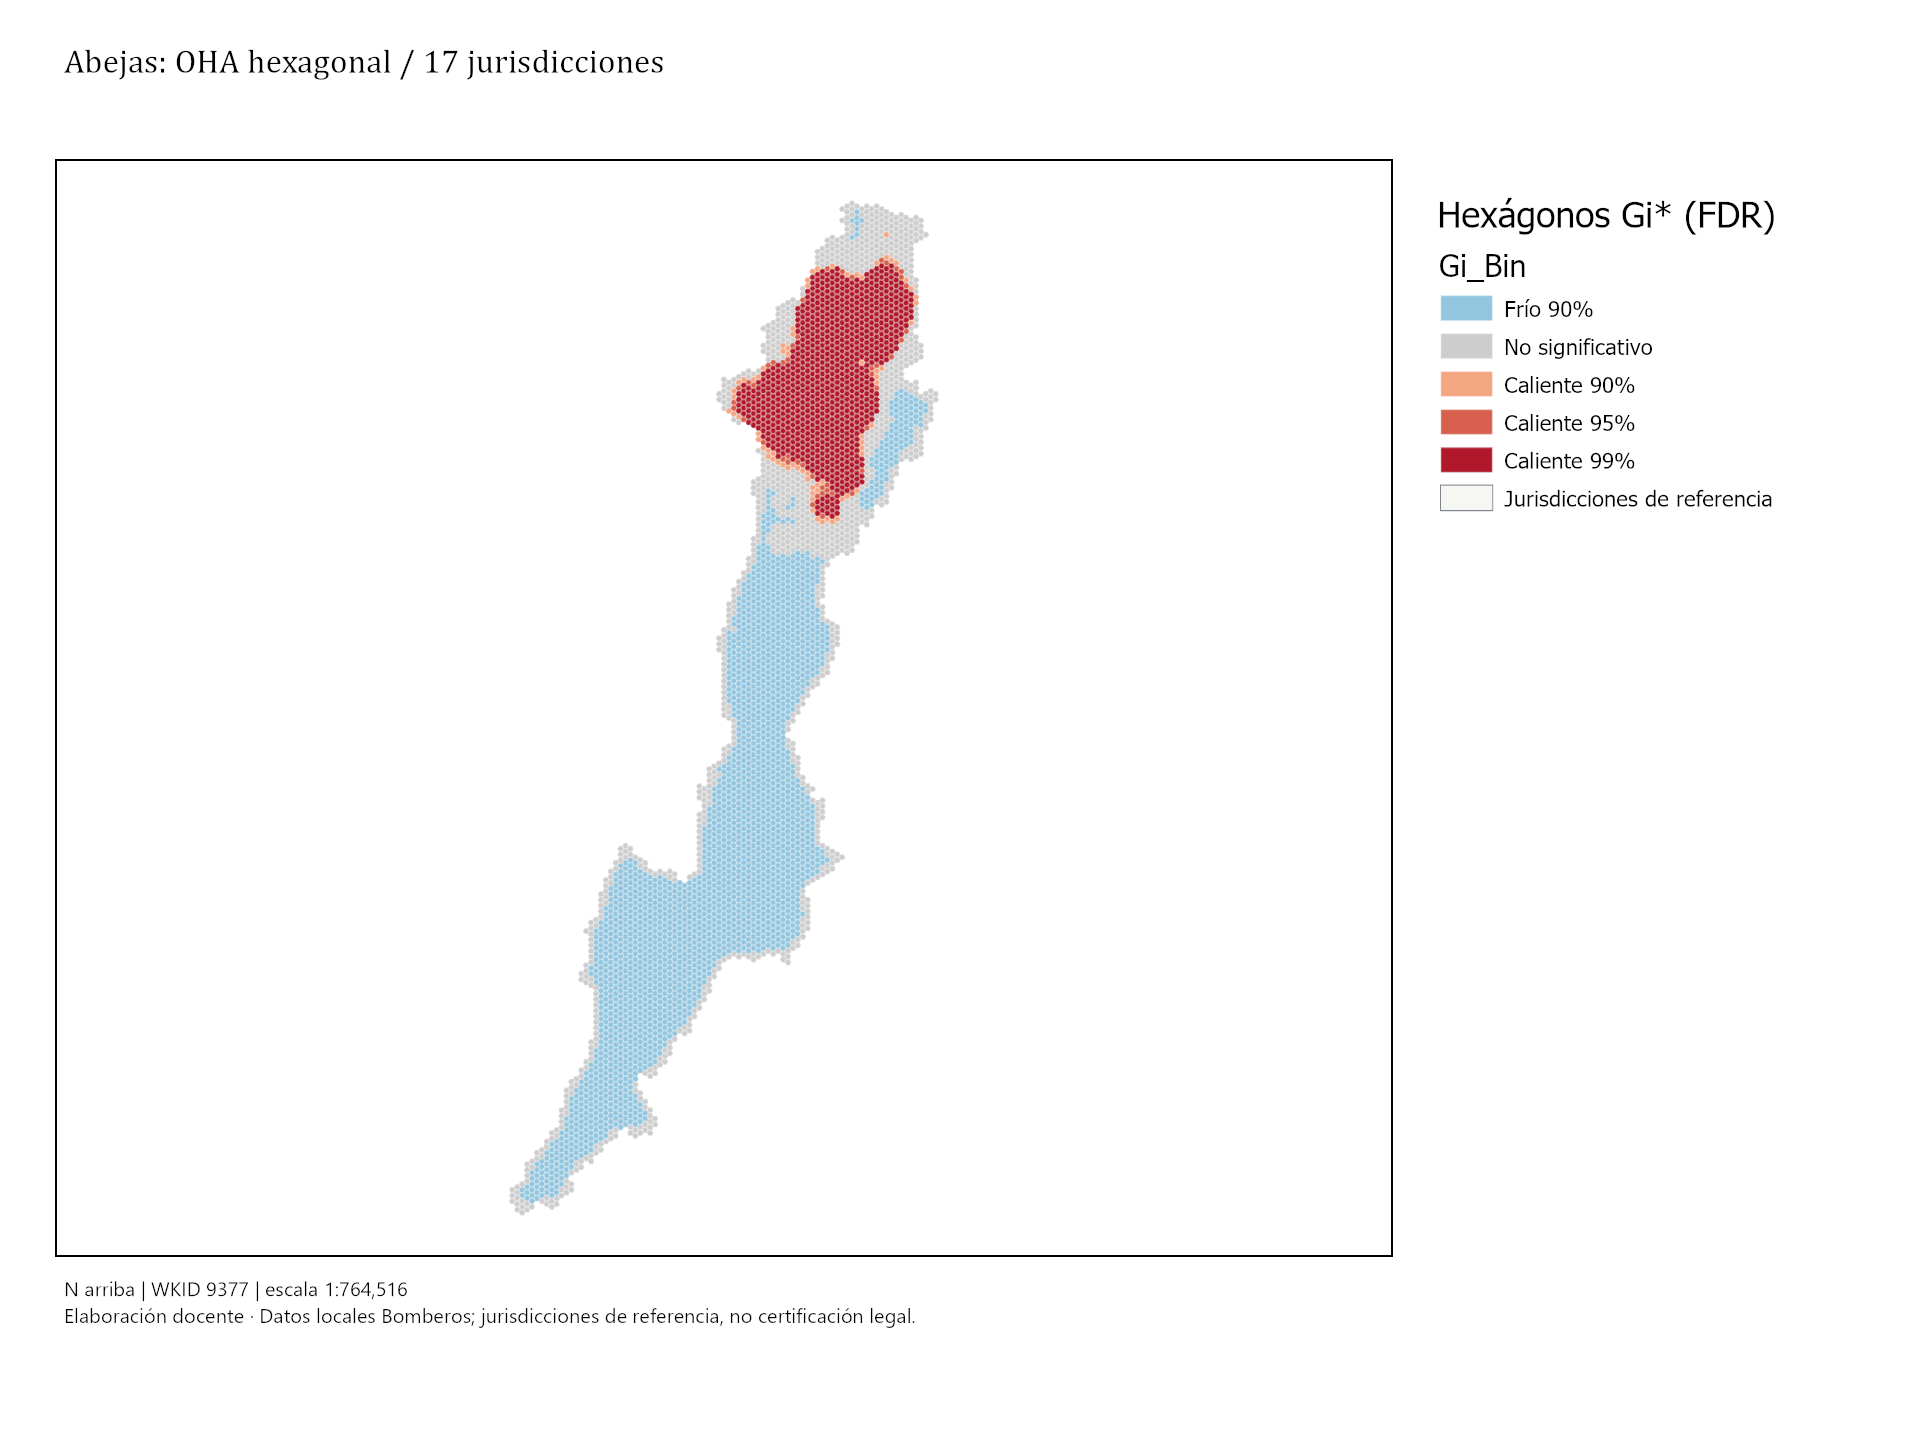

In [16]:
# Mapas nativos de hexágonos con la misma escala cromática en ambos escenarios.
gi_names = {-3:'Frío 99%', -2:'Frío 95%', -1:'Frío 90%', 0:'No significativo', 1:'Caliente 90%', 2:'Caliente 95%', 3:'Caliente 99%'}
gi_colors = [[33,102,172,100], [67,147,195,100], [146,197,222,100], [205,205,205,100],
             [244,165,130,100], [214,96,77,100], [178,24,43,100]]
oha_summaries = []
def oha_map(fc, name, title):
    with arcpy.da.SearchCursor(fc, ['Gi_Bin', 'JOIN_COUNT']) as cursor:
        rows = list(cursor)
    freq = Counter(int(row[0]) for row in rows)
    zeros = sum(row[1] == 0 for row in rows)
    table(['Gi_Bin FDR', 'Clase', 'Hexágonos'], [(v, gi_names[v], freq[v]) for v in range(-3,4)])
    print('Hexágonos:', len(rows), '| ceros:', zeros, '| suma JOIN_COUNT:', sum(row[1] for row in rows))
    oha_summaries.append({'escenario':name, 'hexagonos':len(rows), 'ceros':zeros,
                          'suma_JOIN_COUNT':sum(row[1] for row in rows), 'Gi_Bin':dict(freq)})
    parts = map_setup(fc, name, title, arcpy.Describe(fc).extent)
    layer = parts[2]
    layer.name = 'Hexágonos Gi* (FDR)'
    sym = layer.symbology
    sym.updateRenderer('UniqueValueRenderer')
    sym.renderer.fields = ['Gi_Bin']
    for group in sym.renderer.groups:
        for item in group.items:
            value = int(item.values[0][0])
            item.label = gi_names[value]
            item.symbol.color = {'RGB':gi_colors[value+3]}
            item.symbol.outlineColor = {'RGB':[255,255,255,30]}
    layer.symbology = sym
    # Leyenda con muestras de color reales, separada del marco cartográfico.
    project, m, layer, layout = parts
    frame = layout.listElements('MAPFRAME_ELEMENT')[0]
    legend = layout.createMapSurroundElement(rect(9,3.6,11.8,7.8), 'LEGEND', frame, None, 'Leyenda Gi')
    legend.fittingStrategy = 'AdjustFontSize'
    map_finish(parts, name, '')

oha_map(oha_all, 'oha_17', 'Abejas: OHA hexagonal / 17 jurisdicciones')


**Con las 17 jurisdicciones:** 4 318 hexágonos, 3 534 ceros y 2 173 incidentes contabilizados. Tamaño automático: ancho 796,7434 m y alto 690 m; banda 2 014 m. FDR: 2 329 fríos (90 %), 1 055 no significativos y 934 calientes (74/47/813 a 90/95/99 %). OHA omitió 9 ubicaciones atípicas solo al estimar el tamaño de celda, no del conteo final.

Azul y rojo indican agrupaciones relativas de conteos bajos y altos; gris conserva lo no significativo. La tabla también muestra categorías vacías. El mapa completo incluye el soporte analizado, no solo donde hay puntos. Los límites son una hipótesis operativa de disponibilidad, no una certificación legal.

### ¿Qué ocurre al excluir B-10?
La fuente llama a este escenario «sin Sumapaz» (**71:18–72:23**), pero en los datos **B-10 es Marichuela**. Excluir `ESTACION = 'B-10'` no equivale a retirar un límite administrativo de Sumapaz. Repetimos el análisis con 16 polígonos, sin modificar las abejas ni ajustar las escalas.

Start Time: jueves, 17 de septiembre de 2026 1:15:21 p. m.

************************** Initial Data Assessment ***************************
Making sure there are enough incidents for analysis....
    - There are 2074 valid input features.

Looking for locational outliers....
    - There were 18 outlier locations; these will not be used to compute the hexagon size.

Evaluating the bounding polygon feature class....
    - The total study area is 648134616.7515 square meters.

**************************** Incident Aggregation ****************************
    - Using a hexagon of width 474.5819 meters and height 411.0000 meters

Counting the number of incidents in each hexagon....
    - Analysis is performed on all hexagons within the bounding polygon feature class.

Evaluating incident counts and number of polygons....
    - The aggregation process resulted in 4753 weighted polygons.
    - Incident Count Properties:
        Min:        0.0000
        Max:       10.0000
        Mean:       

Gi_Bin FDR,Clase,Hexágonos
-3,Frío 99%,0
-2,Frío 95%,1277
-1,Frío 90%,544
0,No significativo,1714
1,Caliente 90%,162
2,Caliente 95%,381
3,Caliente 99%,675


Hexágonos: 4753 | ceros: 3569 | suma JOIN_COUNT: 2074


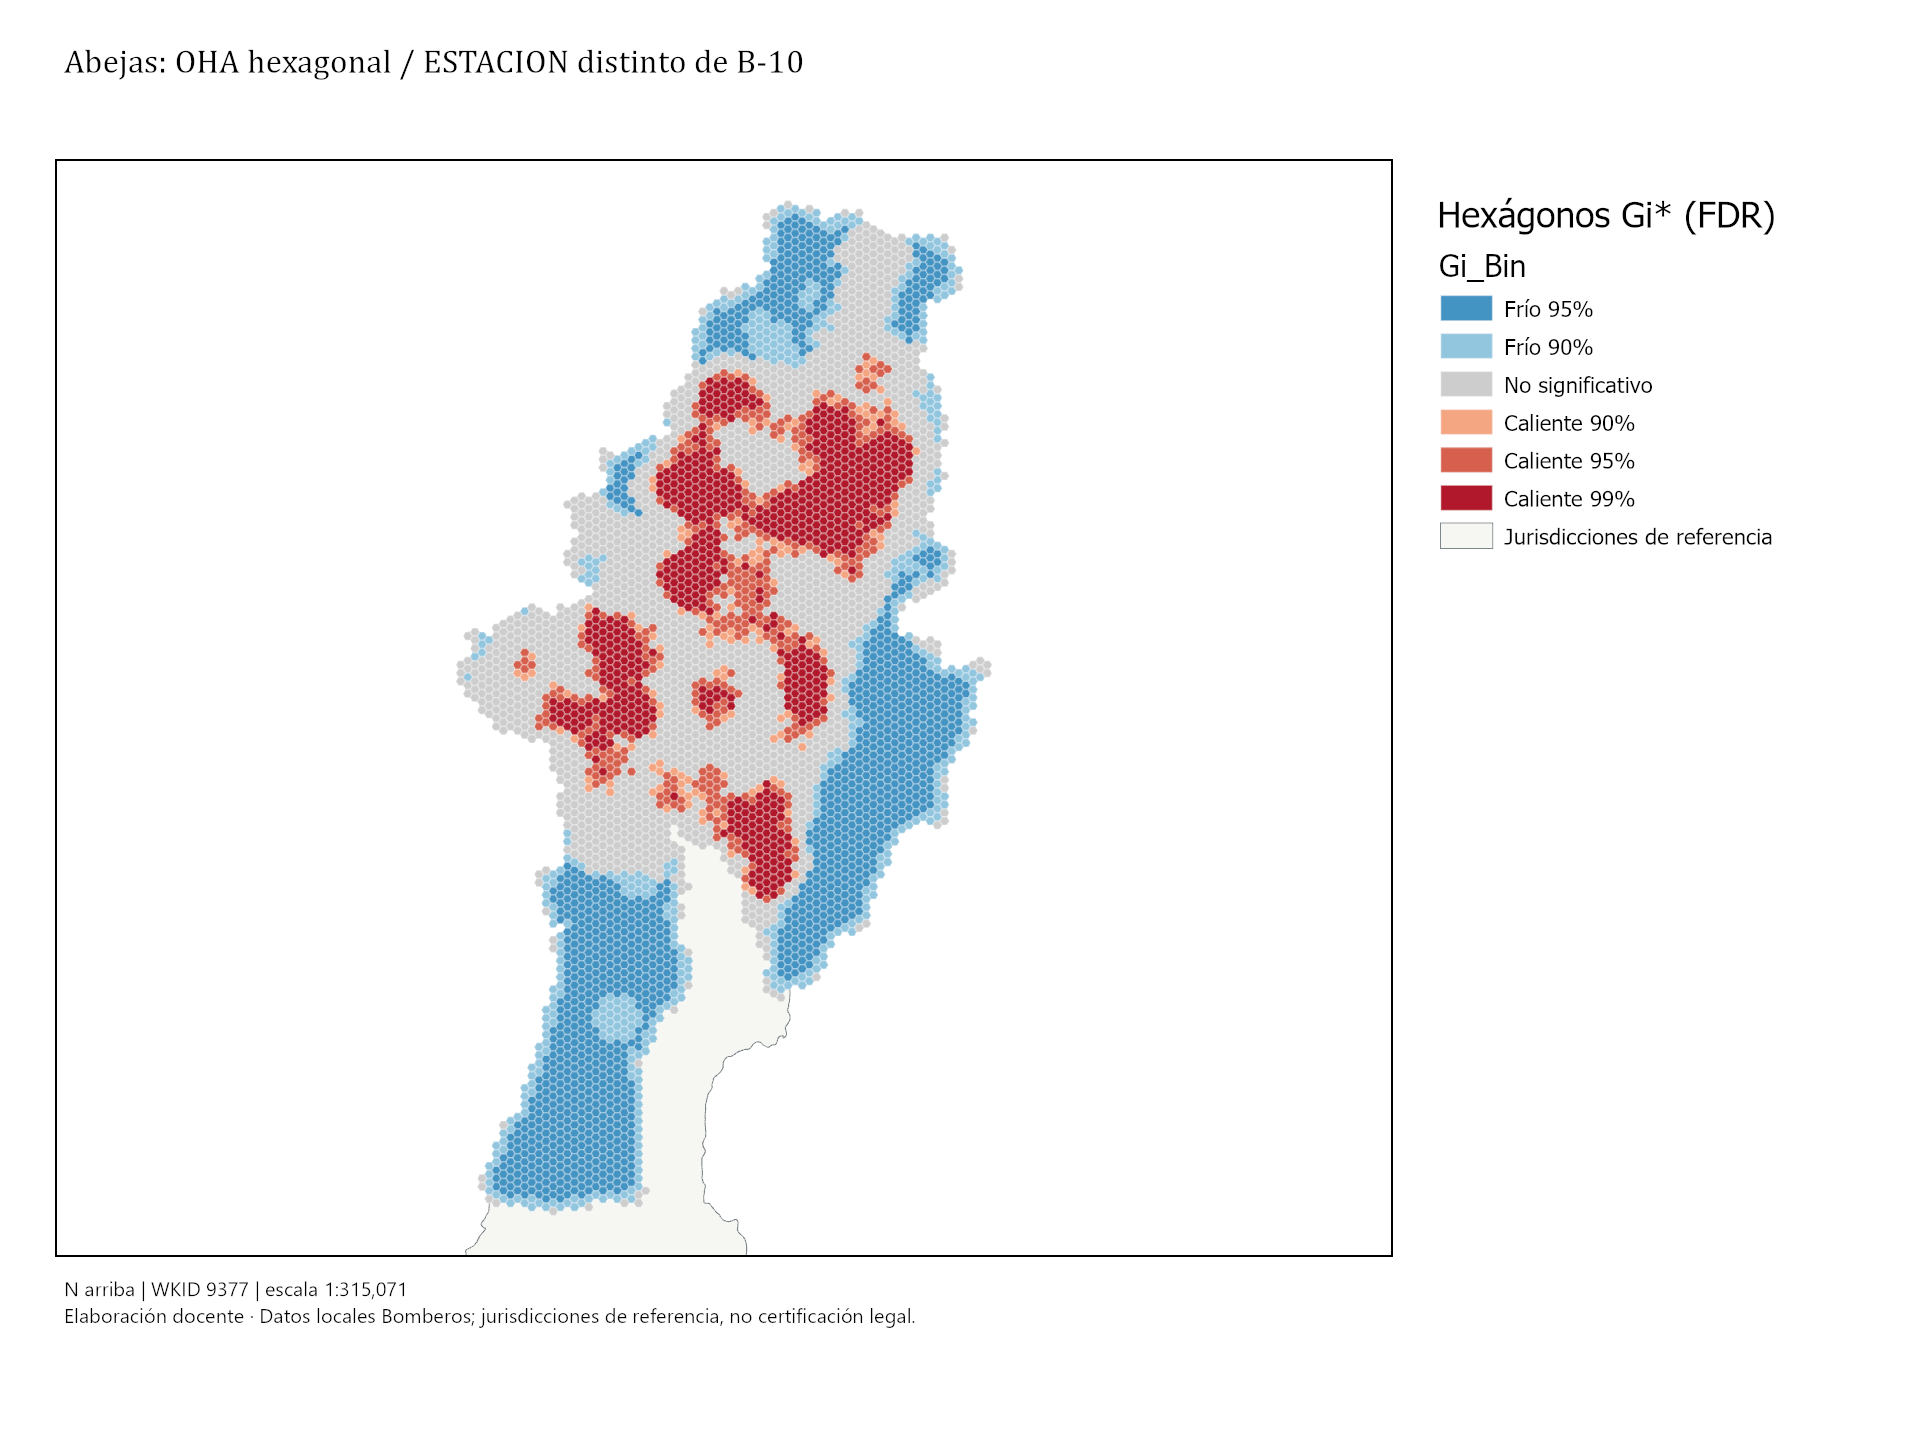

In [17]:
# Segundo análisis: mismas abejas; cambia la delimitación, no se fuerza una escala.
oha_without = str(Path(gdb) / 'OHA_Abejas_16')
result = arcpy.stats.OptimizedHotSpotAnalysis(bees, oha_without, '',
    'COUNT_INCIDENTS_WITHIN_HEXAGON_POLYGONS', without_b10)
messages(result, 'OHA_16')
oha_map(oha_without, 'oha_16', 'Abejas: OHA hexagonal / ESTACION distinto de B-10')


**Sin B-10:** 4 753 hexágonos, 3 569 ceros y 2 074 incidentes contabilizados: 99 menos por la nueva delimitación. Celda automática: ancho 474,5819 m y alto 411 m; banda 1 174 m. Hay 1 821 fríos, 1 714 no significativos y 1 218 calientes; 18 ubicaciones atípicas no se usaron para estimar la celda. Más celdas en menor área refleja también la nueva resolución, no más incidentes.

Compare número de hexágonos, ceros, suma de incidentes y escalas de los mensajes. Cambiar soporte puede cambiar qué incidentes se contabilizan y también la escala automática. Por eso una diferencia de color **no aísla un efecto causal** de excluir una jurisdicción. FDR no corrige la exploración entre ambos escenarios.

## El ensayo de preguntas: HDBSCAN con mínimo 50
La fuente vuelve a **todos los incidentes** en **76:20–76:32**. Reducir el mínimo a 50 permite otra extracción; no garantiza una mejora. Esta comparación sí mantiene la población respecto a HDBSCAN 100, pero las etiquetas siguen siendo nominales.

Start Time: jueves, 17 de septiembre de 2026 1:16:05 p. m.
Number of Clusters 5
Noise features 2463
Succeeded at jueves, 17 de septiembre de 2026 1:16:47 p. m. (Elapsed Time: 42.33 seconds)


Configuración,Universo,Filas,Grupos,Ruido
HDBSCAN mínimo 50,Todos,90443,5,2463


Ruido no es error; las etiquetas solo identifican grupos de esta corrida.


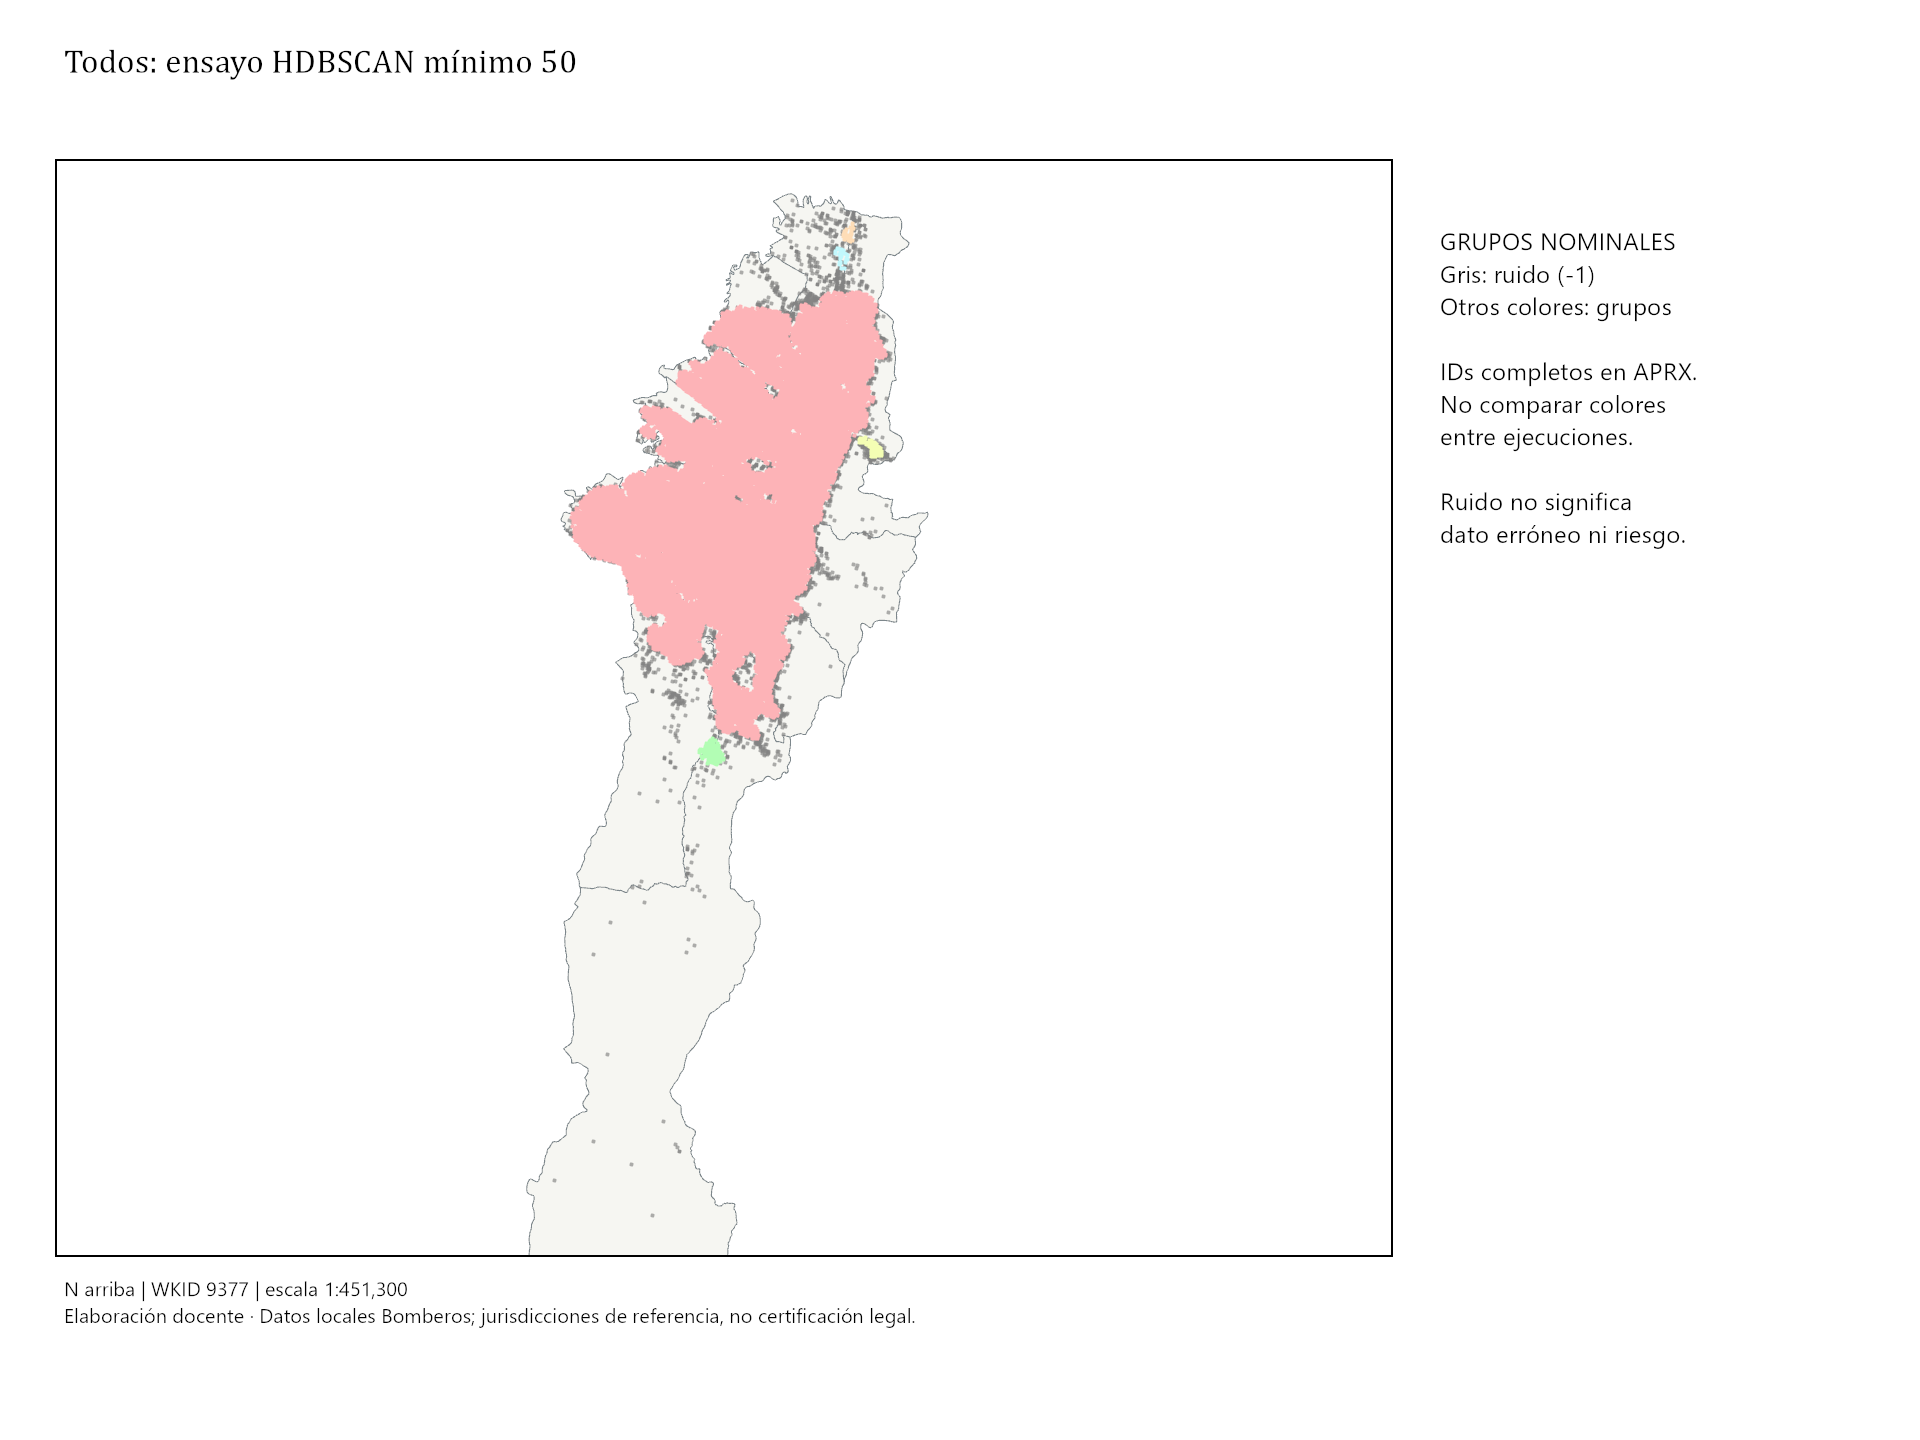

Configuración,Universo,Filas,Grupos,Ruido
DBSCAN 100 / 350 m,Abejas,2173,0,2173
Todos: DBSCAN 100 / 350 m,Todos,90443,20,13384
Todos: DBSCAN 50 / 100 m,Todos,90443,5,90087
Todos: HDBSCAN mínimo 100,Todos,90443,3,1187
Todos: OPTICS 100 / 350 m automático,Todos,90443,29,17561
HDBSCAN mínimo 50,Todos,90443,5,2463


In [18]:
# Ensayo posterior de la fuente: TODOS, no abejas.
hdb50 = str(Path(gdb) / 'HDBSCAN_Todos_50')
result = arcpy.stats.DensityBasedClustering(incidents, hdb50, 'HDBSCAN', 50)
messages(result, 'HDBSCAN_Todos_50')
cluster_summary(hdb50, 'HDBSCAN mínimo 50', 'Todos')
point_map(hdb50, 'HDBSCAN_Todos_50', 'Todos: ensayo HDBSCAN mínimo 50', cluster=True)
table(['Configuración', 'Universo', 'Filas', 'Grupos', 'Ruido'], cluster_summaries)


**HDBSCAN 50 observado:** 5 grupos y 2 463 puntos ruido. Frente al mínimo 100 aumentan ambos recuentos: no hay una regla de mejora monótona.

Compare HDBSCAN 100 y 50 leyendo grupo y ruido conjuntamente. Más grupos no significa más exactitud. Mantenga aparte la fila de abejas: su denominador es distinto.

## Antes de Moran: ¿qué significa hacer coincidir posiciones?
En **111:50–112:22**, la demostración usa **Integrate → Collect Events** sobre abejas. Integrate **mueve coordenadas in situ** según la tolerancia XY del CRS; una coincidencia previa no demuestra un error. Aquí reproducimos el paso autorizado **solo en una copia nueva para Moran**, nunca en las abejas de clustering/OHA.

Creamos `ORIG_OID` en esa copia para enlazar cada fila con el OID de la entrada, aunque la nueva geodatabase renumere filas. Comprobamos cantidad, identidad y atributos antes/después; mostramos únicamente resúmenes, no identificadores personales. [Esri, Integrate, Pro 3.6, Usage/Parameters](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/data-management/integrate.htm), consulta 2026-09-17. No se usa una tolerancia fija de 10 m.

In [19]:
# Copia nueva con enlace estable al OID de abejas; los atributos solo se comparan en memoria.
integrated = str(Path(gdb) / 'Abejas_solo_Moran')
attrs = [f.name for f in arcpy.ListFields(bees) if f.type not in ('OID', 'Geometry')]
assert 'ORIG_OID' not in attrs
arcpy.management.CreateFeatureclass(gdb, 'Abejas_solo_Moran', 'POINT', template=bees, spatial_reference=sr)
arcpy.management.AddField(integrated, 'ORIG_OID', 'LONG')
with arcpy.da.SearchCursor(bees, ['OID@', 'SHAPE@'] + attrs) as source_cursor:
    with arcpy.da.InsertCursor(integrated, ['ORIG_OID', 'SHAPE@'] + attrs) as target_cursor:
        for row in source_cursor:
            target_cursor.insertRow(row)

def snapshot(fc, id_field):
    # Ningún valor de atributo ni ID se imprime o se exporta a archivos auxiliares.
    with arcpy.da.SearchCursor(fc, [id_field, 'SHAPE@XY'] + attrs) as cursor:
        rows = list(cursor)
    result = {row[0]:(row[1], tuple(row[2:])) for row in rows}
    if len(result) != len(rows):
        raise ValueError('El identificador de correspondencia no es único.')
    return result

bee_snapshot = snapshot(bees, 'OID@')
before_integrate = snapshot(integrated, 'ORIG_OID')
assert before_integrate == bee_snapshot
print('Copia verificada:', len(before_integrate), 'filas con IDs, atributos y XY conservados.')
print('Tolerancia XY nativa:', arcpy.Describe(integrated).spatialReference.XYTolerance, sr.linearUnitName)


Copia verificada: 2173 filas con IDs, atributos y XY conservados.
Tolerancia XY nativa: 0.001 Meter


In [20]:
# La tabla de valores [[copia, rango]] conserva rutas con espacios.
# Integrate actúa exclusivamente sobre la copia nueva; tolerancia omitida = valor del CRS.
result = arcpy.management.Integrate([[integrated, 1]])
messages(result, 'Integrate_solo_Moran')
after_integrate = snapshot(integrated, 'ORIG_OID')
assert before_integrate.keys() == after_integrate.keys()
assert all(before_integrate[k][1] == after_integrate[k][1] for k in before_integrate)
assert snapshot(bees, 'OID@') == bee_snapshot
moves = [math.dist(before_integrate[k][0], after_integrate[k][0]) for k in before_integrate]
integrate_summary = {'filas':len(moves), 'movidas':sum(d > 0 for d in moves),
    'desplazamiento_max_m':max(moves), 'tolerancia_XY_m':arcpy.Describe(integrated).spatialReference.XYTolerance,
    'ids_y_atributos_conservados':True, 'abejas_clustering_OHA_intactas':True}
print(integrate_summary)


Start Time: jueves, 17 de septiembre de 2026 1:16:54 p. m.
Reading Features...
Cracking Features...
Assembling Features...
Features were updated 31 times.
Succeeded at jueves, 17 de septiembre de 2026 1:16:55 p. m. (Elapsed Time: 0.16 seconds)


{'filas': 2173, 'movidas': 31, 'desplazamiento_max_m': 0.0013601473422912788, 'tolerancia_XY_m': 0.001, 'ids_y_atributos_conservados': True, 'abejas_clustering_OHA_intactas': True}


**Efecto observado de Integrate:** las 2 173 filas conservaron IDs y atributos; 31 cambiaron XY. Tolerancia nativa 0,001 m; desplazamiento máximo medido 0,001360147 m. La copia de clustering/OHA quedó intacta.

El conteo de movidas y el desplazamiento máximo cuantifican el efecto local: no certifican que las posiciones nuevas sean más correctas. La tolerancia configura coincidencia geométrica, no precisión del levantamiento.

### Pasar de registros a sitios ocupados
**Collect Events** reúne posiciones coincidentes y crea `ICOUNT`: cantidad de atenciones por sitio. No elimina eventos: su suma debe recuperar todas las abejas. La fuente muestra **2 029 sitios**; es una referencia para contrastar, no un valor que debamos forzar. Los sitios sin registros no aparecen con cero, a diferencia de los hexágonos OHA.

[Esri, Collect Events, Pro 3.6, Usage/Python](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/collect-events.htm), consulta 2026-09-15.

Start Time: jueves, 17 de septiembre de 2026 1:16:57 p. m.
Succeeded at jueves, 17 de septiembre de 2026 1:17:03 p. m. (Elapsed Time: 6.59 seconds)
Atenciones: 2173 | sitios locales: 2029 | referencia video: 2029
Diferencia respecto a fuente: 0 | rango ICOUNT: 1 4
Media por sitio ocupado: 1.070970921636274 | frecuencias: {1: 1898, 2: 120, 3: 9, 4: 2}


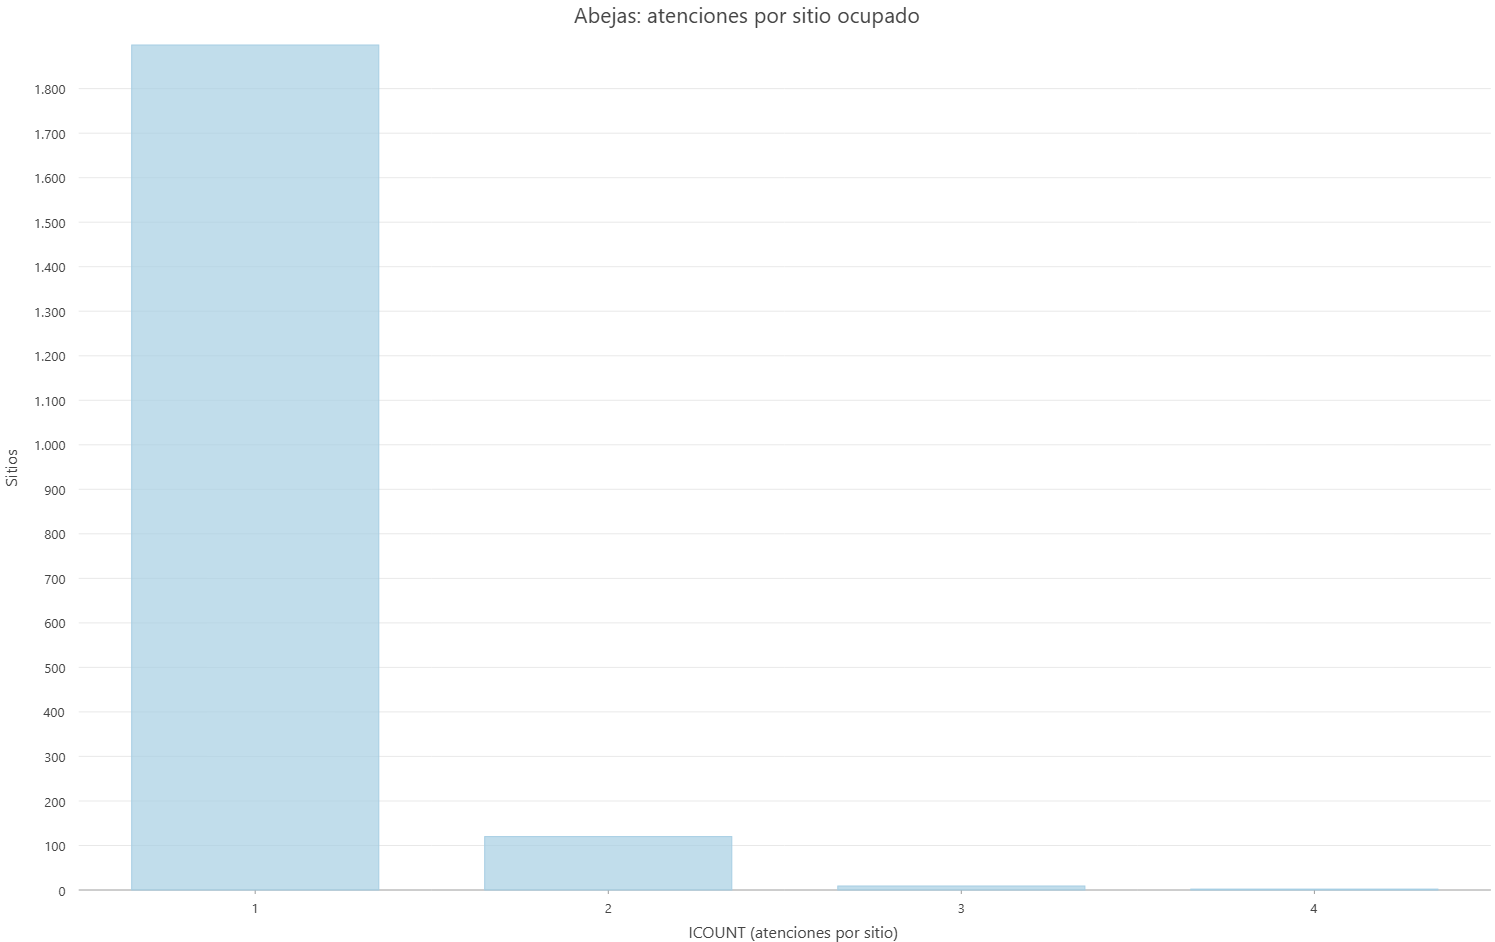

In [21]:
# Conteos exactos después de Integrate; verificar posiciones y suma sin deduplicar.
weighted = str(Path(gdb) / 'Abejas_ICOUNT')
result = arcpy.stats.CollectEvents(integrated, weighted)
messages(result, 'CollectEvents')
expected_sites = Counter(value[0] for value in after_integrate.values())
with arcpy.da.SearchCursor(weighted, ['SHAPE@XY', 'ICOUNT']) as cursor:
    actual_sites = dict(cursor)
assert actual_sites == dict(expected_sites)
icount = list(actual_sites.values())
assert sum(icount) == n_bees
print('Atenciones:', sum(icount), '| sitios locales:', len(icount), '| referencia video: 2029')
print('Diferencia respecto a fuente:', len(icount)-2029, '| rango ICOUNT:', min(icount), max(icount))
print('Media por sitio ocupado:', sum(icount)/len(icount), '| frecuencias:', dict(sorted(Counter(icount).items())))
chart_png(arcpy.charts.Bar(x='ICOUNT', aggregation='COUNT', dataSource=weighted,
    title='Abejas: atenciones por sitio ocupado', xTitle='ICOUNT (atenciones por sitio)', yTitle='Sitios'), 'icount_frecuencia')


**Resultado local:** 2 173 atenciones en 2 029 sitios, igual al número mostrado por la fuente. Las frecuencias de ICOUNT 1/2/3/4 son 1 898/120/9/2 sitios; media 1,070971. Las barras pequeñas se leen con esos conteos, sin ocultarlas ni borrar extremos.

La barra de `ICOUNT=1` cuenta sitios con una sola atención; no cuenta territorios con cero. Media mayor que uno puede surgir de una minoría de sitios con varias atenciones. La unidad es **atenciones/sitio ocupado**, no abundancia de abejas ni riesgo poblacional.

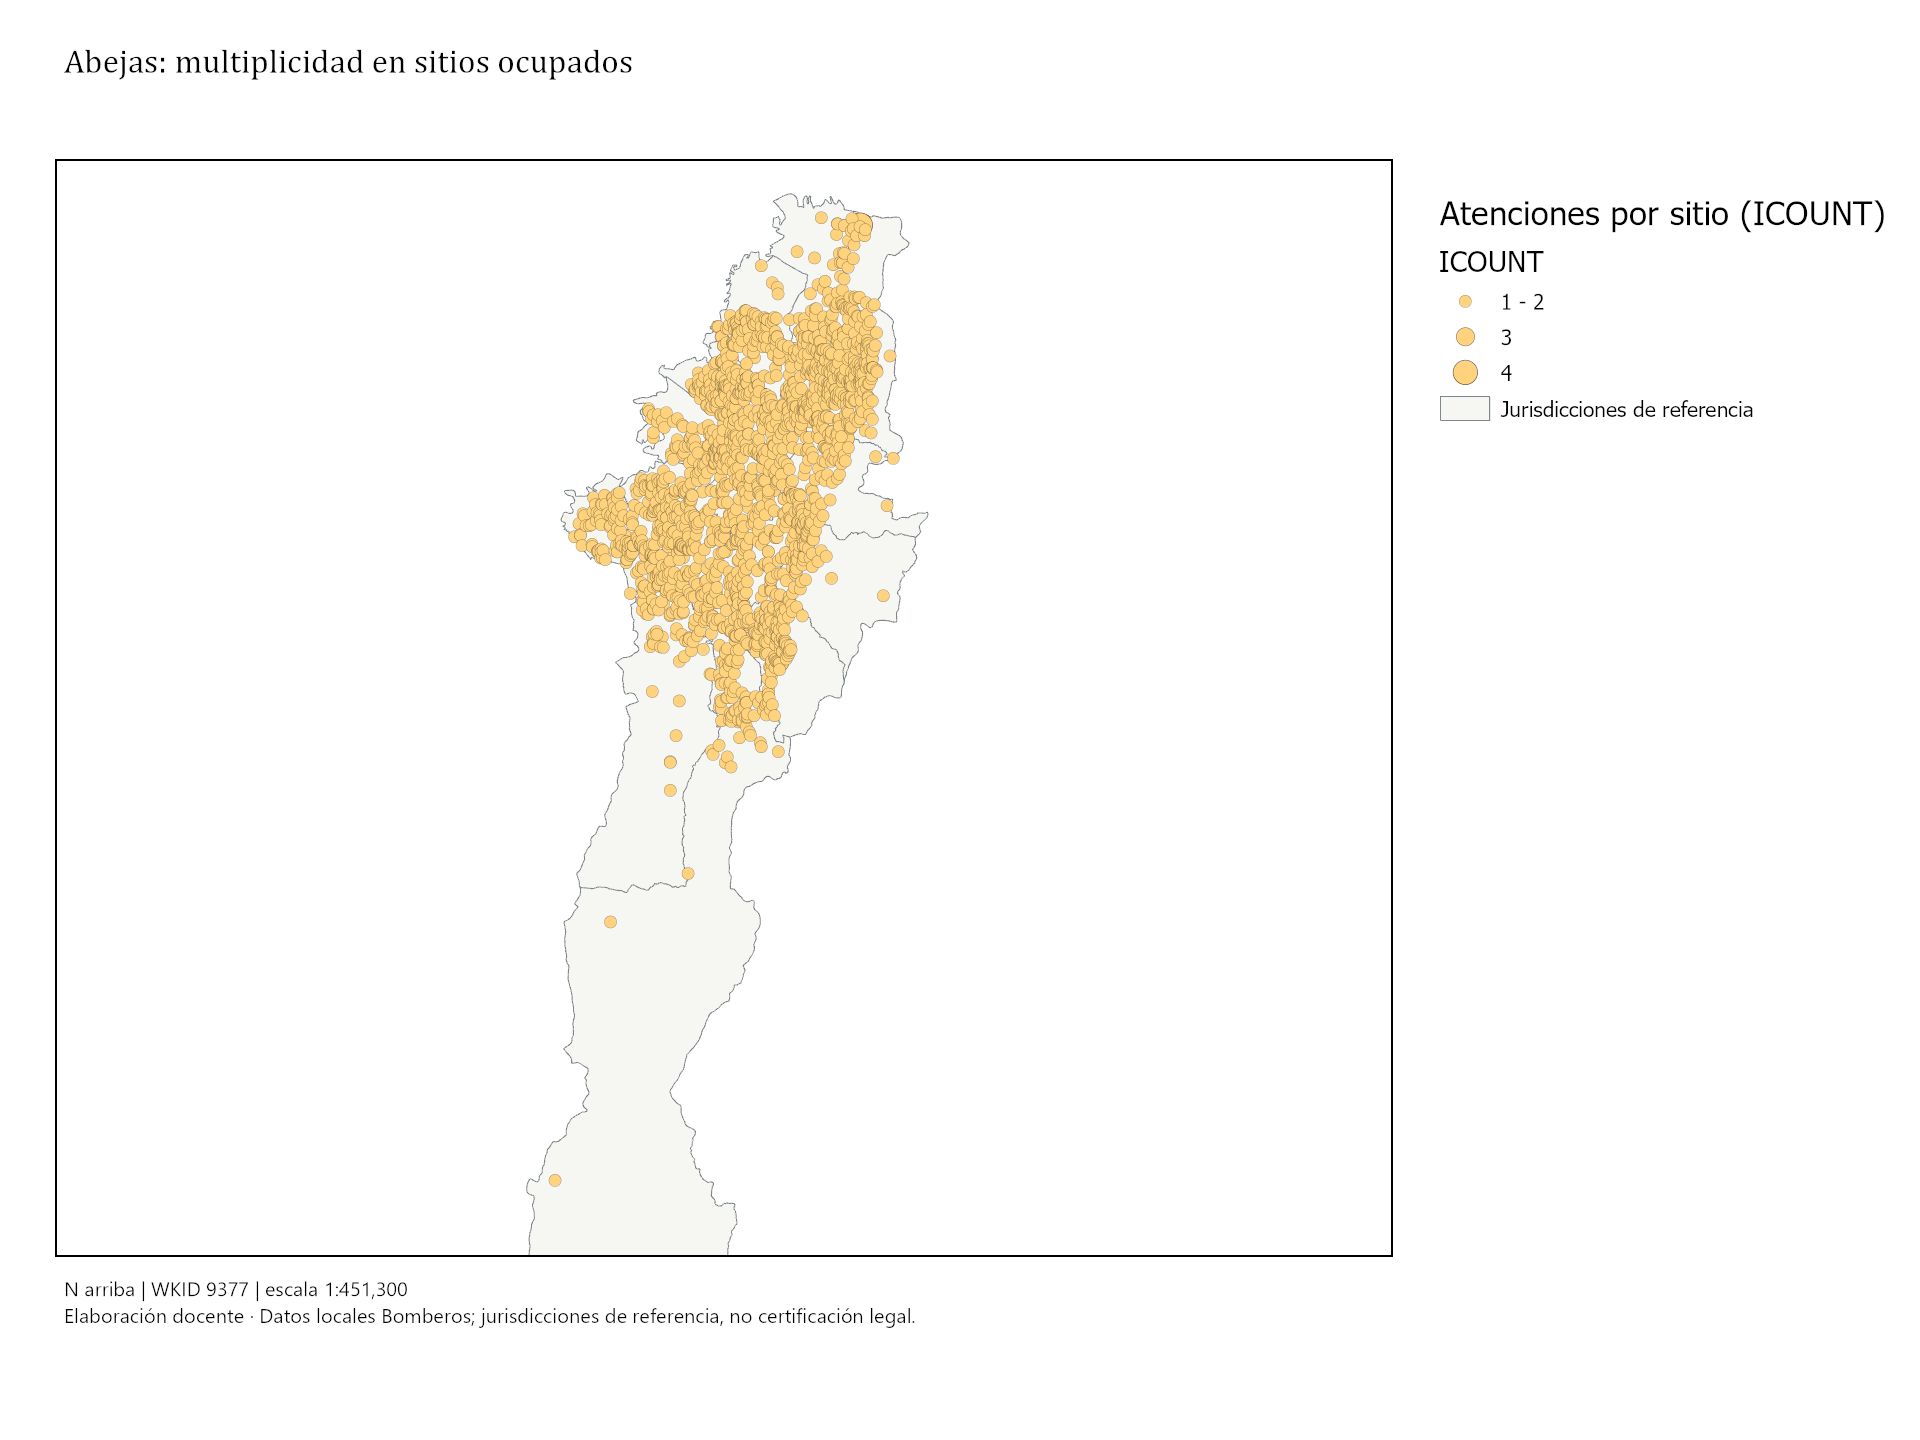

In [22]:
# Mapa descriptivo de multiplicidad; no usar colores de significancia.
parts = map_setup(weighted, 'icount_mapa', 'Abejas: multiplicidad en sitios ocupados')
layer = parts[2]
layer.name = 'Atenciones por sitio (ICOUNT)'
sym = layer.symbology
sym.updateRenderer('GraduatedSymbolsRenderer')
sym.renderer.classificationField = 'ICOUNT'
layer.symbology = sym
project, m, layer, layout = parts
frame = layout.listElements('MAPFRAME_ELEMENT')[0]
legend = layout.createMapSurroundElement(rect(9,3.6,11.8,7.8), 'LEGEND', frame, None, 'Leyenda ICOUNT')
legend.fittingStrategy = 'AdjustFontSize'
map_finish(parts, 'icount_mapa', '')


**Lectura del mapa:** la clasificación automática agrupa ICOUNT 1–2 y separa 3 y 4. El tamaño menor no distingue uno de dos registros; use las barras para esa diferencia.

El tamaño representa multiplicidad según las clases de la leyenda. El mapa devuelve la posición que las barras no muestran; no convierte concentración visual en significancia.

## ¿Se parecen los conteos de sitios vecinos?
**Moran incremental** contrasta semejanza de `ICOUNT` entre sitios vecinos, no densidad de los puntos originales. Seguimos **114:20–116:05**: diez distancias, inicio 100 m e incremento 100 m, distancia euclidiana y estandarización por fila (`ROW_STANDARDIZATION`). Son radios acumulativos de 100 a 1 000 m, no anillos. Por fila significa dividir pesos por su suma, no eliminar dependencia.

Moran I resume productos de desviaciones respecto de la media. Su esperado bajo el modelo nulo y su varianza permiten calcular `z = (I − E[I]) / √Var(I)`. La varianza es la de **I bajo el modelo nulo**, no la de distancias. `p` expresa extremidad bajo ese modelo, no probabilidad de que la hipótesis sea cierta.

[Esri, Incremental Spatial Autocorrelation, Pro 3.6, Parameters](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/incremental-spatial-autocorrelation.htm) y [How it works, picos y escala](https://pro.arcgis.com/en/pro-app/3.6/tool-reference/spatial-statistics/how-incremental-spatial-autocorrelation-works.htm), consulta 2026-09-15.

Start Time: jueves, 17 de septiembre de 2026 1:17:08 p. m.


WARNING 001284: No valid peaks found at the specified distances.

            Global Moran's I Summary by Distance            
Distance Moran's Index Expected Index Variance   z-score  p-value
  100.00      0.000113      -0.001538 0.002442  0.033428 0.973333
  200.00     -0.002673      -0.000812 0.001096 -0.056217 0.955169
  300.00      0.024537      -0.000620 0.000635  0.998451 0.318061
  400.00      0.014060      -0.000547 0.000404  0.726427 0.467577
  500.00      0.012315      -0.000516 0.000280  0.766120 0.443605
  600.00      0.014480      -0.000504 0.000197  1.067328 0.285824
  700.00      0.014074      -0.000501 0.000143  1.220846 0.222144
  800.00      0.007406      -0.000499 0.000106  0.766903 0.443139
  900.00      0.002193      -0.000498 0.000085  0.291483 0.770682
 1000.00      0.001943      -0.000498 0.000069  0.294252 0.768565
First Peak (Distance; Value): None; None
Max Peak (Distance; Value): None; None
Distan

Distance,MoransI,ExpectedI,Variance,z_score,p_value
100.0,0.00011344884488264067,-0.0015384615384615385,0.002442054265717161,0.03342787949132005,0.9733333774605467
200.0,-0.002672514839816935,-0.0008116883116883117,0.0010956589507180058,-0.05621706826653462,0.9551688841525325
300.0,0.02453690909468361,-0.0006203473945409429,0.0006348523274615461,0.9984513753521673,0.3180605451644781
400.0,0.014059700032046023,-0.0005470459518599562,0.00040431836996117387,0.7264266022356316,0.46757729341948373
500.0,0.012314526587239498,-0.0005157297576070139,0.00028046378666584786,0.7661202414596169,0.44360476643936964
600.0,0.01447989458180699,-0.0005035246727089627,0.00019707237661774612,1.0673283736017187,0.2858235958625299
700.0,0.014073581464602448,-0.0005005005005005005,0.00014250845322035606,1.2208460278976216,0.2221443456223695
800.0,0.007406153026049141,-0.0004985044865403788,0.00010623943888517691,0.7669025357209779,0.4431394723268596
900.0,0.00219332775170706,-0.0004977600796416127,8.523736079313096e-05,0.29148276148799396,0.7706821264992092
1000.0,0.001942751515671506,-0.0004975124378109452,6.877548629639182e-05,0.2942523702358381,0.7685650657061344


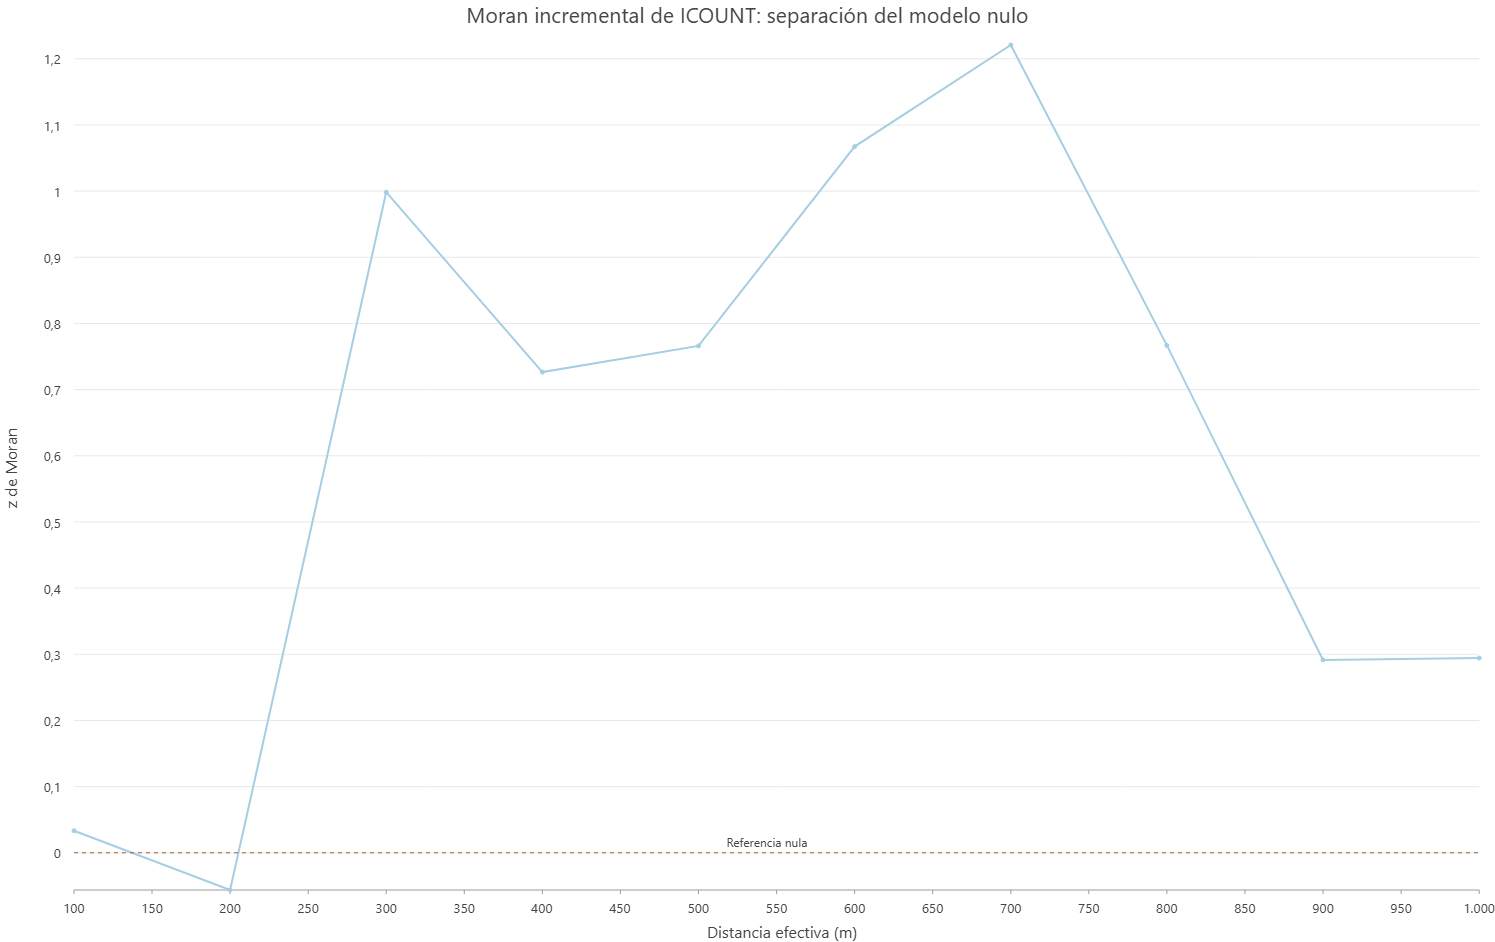

Máximo numérico de z: distancia, I, esperado, varianza, z, p = (700.0, 0.014073581464602448, -0.0005005005005005005, 0.00014250845322035606, 1.2208460278976216, 0.2221443456223695)


In [23]:
# Diez bandas previstas: conservar tabla, informe nativo y mensajes completos.
if len(set(icount)) < 2:
    raise ValueError('ICOUNT constante: Moran no definido; no sustituir ni modificar datos.')
moran_table = str(Path(gdb) / 'Incremental_Abejas')
report = run / 'incremental_abejas.pdf'
result = arcpy.stats.IncrementalSpatialAutocorrelation(weighted, 'ICOUNT', 10, 100, 100,
    'EUCLIDEAN', 'ROW_STANDARDIZATION', moran_table, str(report))
messages(result, 'Moran_incremental')
columns = ['Distance', 'MoransI', 'ExpectedI', 'Variance', 'z_score', 'p_value']
with arcpy.da.SearchCursor(moran_table, columns) as cursor:
    moran_rows = sorted(list(cursor))
table(columns, moran_rows)
curve = arcpy.charts.Line(x='Distance', y='z_score', dataSource=moran_table,
    title='Moran incremental de ICOUNT: separación del modelo nulo', xTitle='Distancia efectiva (m)', yTitle='z de Moran')
for value, label in [(-1.96, '-1.96 nominal'), (0, 'Referencia nula'), (1.96, '+1.96 nominal')]:
    curve.yAxis.addGuide(arcpy.charts.Guide('line', valueFrom=value, label=label,
        lineColor='#996633', lineWidth=1, lineDashStyle='dash'))
chart_png(curve, 'moran_curva_z')
# Incrustar el PDF real: no depende de que Jupyter sirva OUTPUT_DIR.
from base64 import b64encode
pdf_bytes = report.read_bytes()
if not pdf_bytes.startswith(b'%PDF-'):
    raise ValueError('El informe existente no tiene cabecera PDF.')
pdf_data = b64encode(pdf_bytes).decode('ascii')
display(HTML('<a download="' + escape(report.name, quote=True) + '" href="data:application/pdf;base64,'
    + pdf_data + '">Descargar informe PDF nativo de ArcGIS</a>'
    + '<p>El PDF está incrustado. Si el visor bloquea la descarga, abra incremental_abejas.pdf '
    + 'en la carpeta de esta ejecución dentro de OUTPUT_DIR; no requiere un enlace servido por Jupyter.</p>'))
max_row = max(moran_rows, key=lambda row: row[4])
print('Máximo numérico de z: distancia, I, esperado, varianza, z, p =', max_row)


**Resultado de Moran:** WARNING 001284, sin picos válidos. Máximo numérico a 700 m: I=0,014074, z=1,220846, p=0,222144. A 300 m: I=0,024537, z=0,998451, p=0,318061. Ninguna banda resulta significativa al 5 % nominal. El eje vertical está ampliado al rango observado: las referencias ±1,96 quedan fuera del encuadre; la altura aparente no implica significancia.

Lea distancia, I, z y p conjuntamente. Los umbrales ±1.96 son referencias **nominales de una prueba fijada**, no corrección por explorar diez bandas. Las bandas comparten datos y vecinos; sus pruebas no son independientes. Un máximo de z no necesariamente es un pico local válido. Si no hay picos significativos, eso **no demuestra aleatoriedad completa**.

## ¿Y si probamos DBSCAN a 300 m?
El video hace esta demostración en **118:10–118:16**: **abejas, mínimo 100, distancia 300 m**. Volvemos a las abejas **sin Integrate**, porque el desplazamiento se autorizó únicamente para Moran.

**Corrección docente:** un máximo no significativo de la curva no selecciona un radio óptimo de DBSCAN ni valida agrupaciones. Reproducimos un ensayo, no una optimización ni una búsqueda oculta de parámetros.

Start Time: jueves, 17 de septiembre de 2026 1:17:17 p. m.
WARNING 110142: No clusters detected.
Succeeded at jueves, 17 de septiembre de 2026 1:17:21 p. m. (Elapsed Time: 3.94 seconds)


Configuración,Universo,Filas,Grupos,Ruido
DBSCAN 100 / 300 m (ensayo),Abejas sin integrar,2173,0,2173


Ruido no es error; las etiquetas solo identifican grupos de esta corrida.


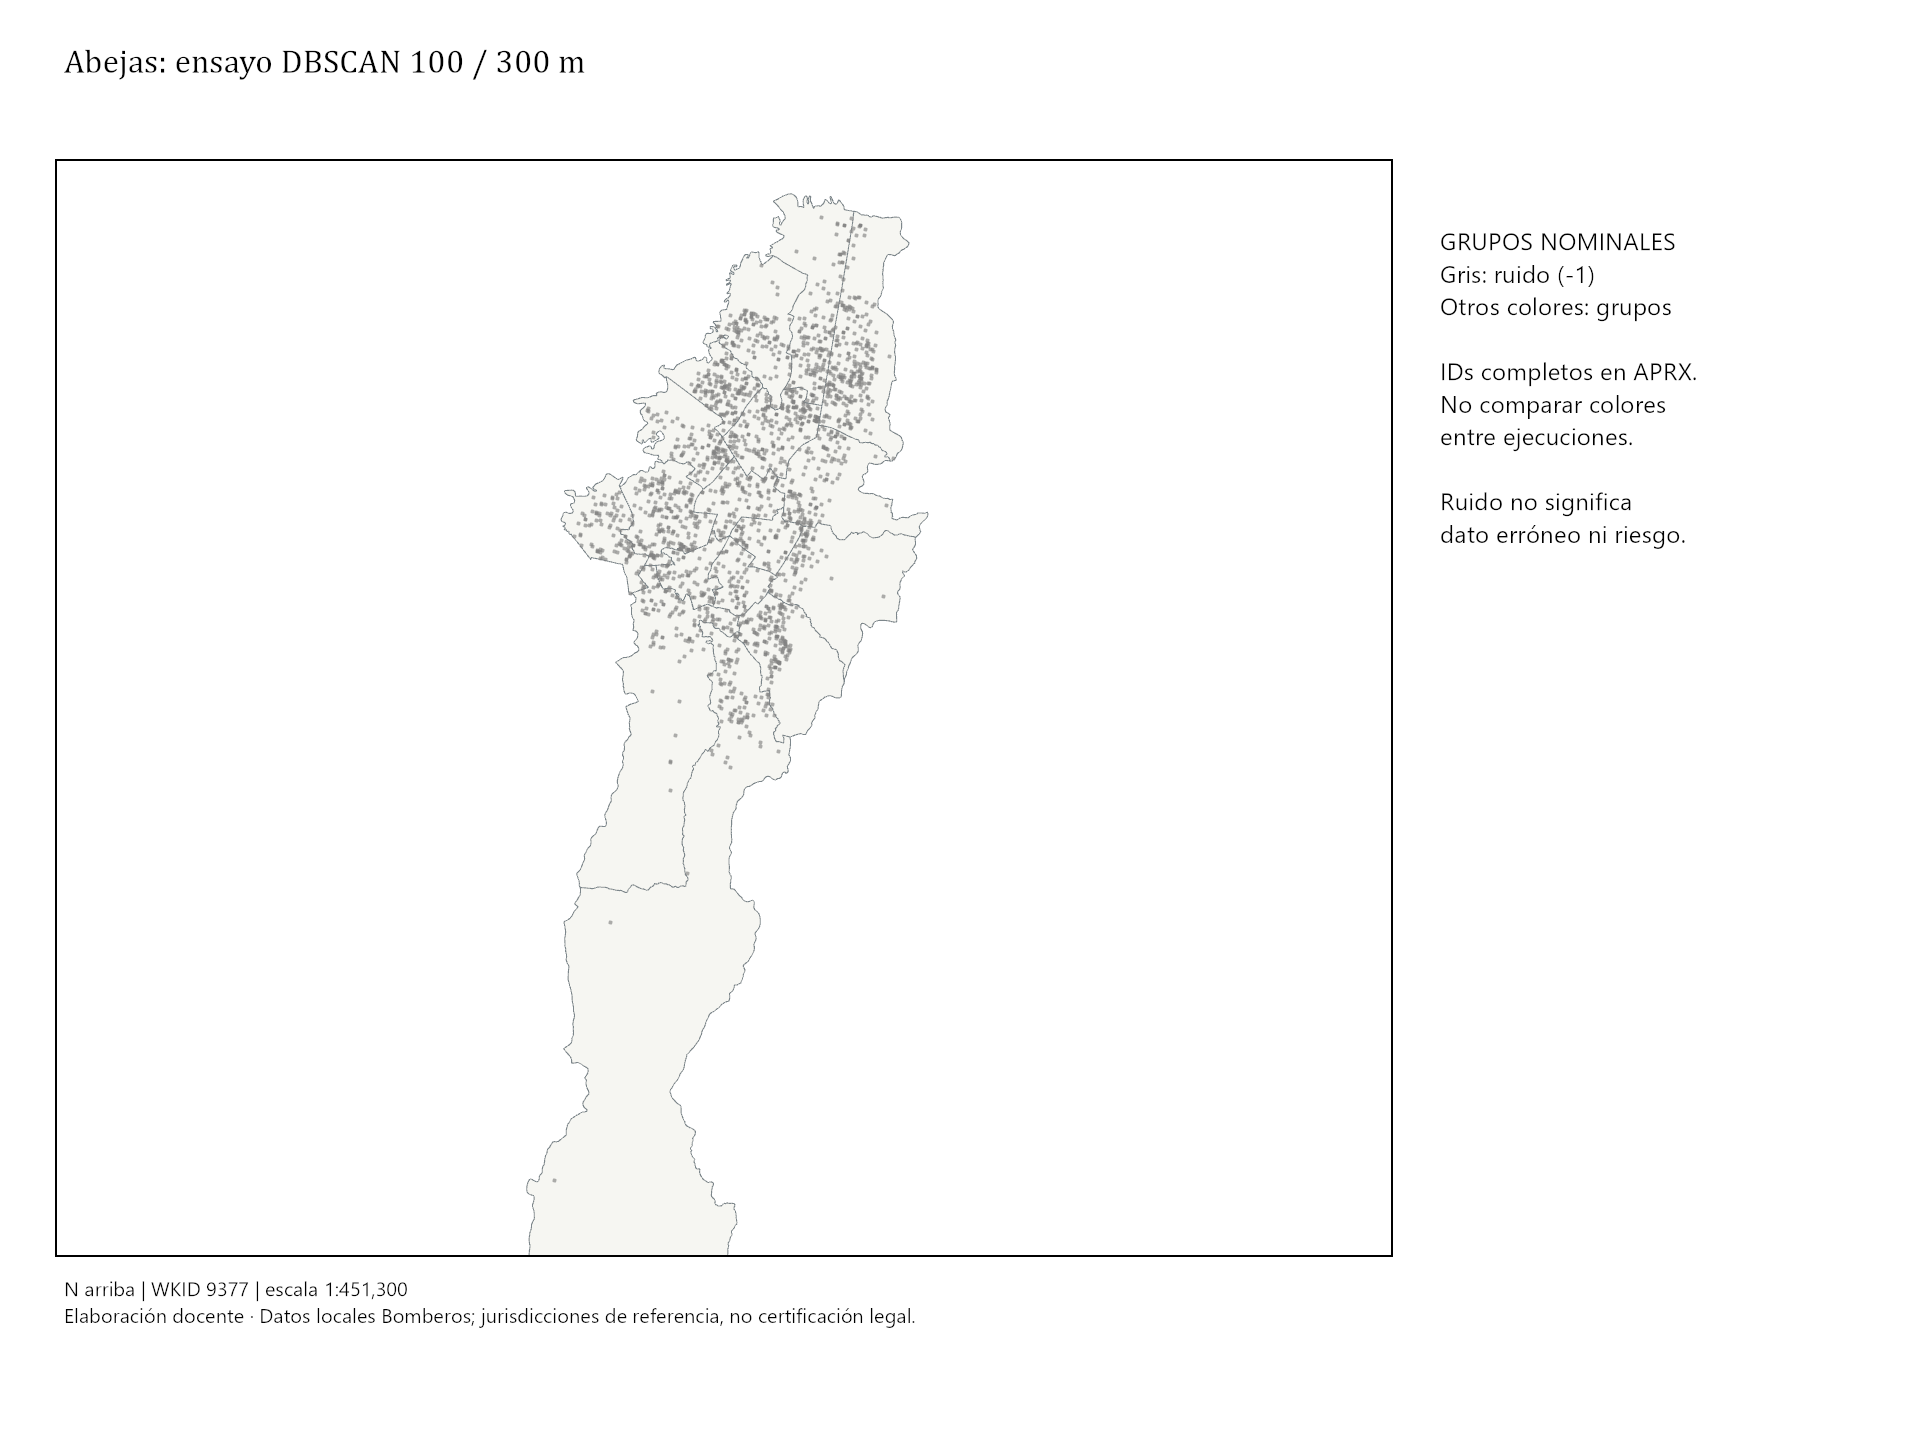

Entrada original y abejas de clustering/OHA: coordenadas conservadas.


In [24]:
# Demostración de fuente, no radio óptimo: abejas originales de clustering.
bee300 = str(Path(gdb) / 'DBSCAN_Abejas_100_300')
result = arcpy.stats.DensityBasedClustering(bees, bee300, 'DBSCAN', 100, '300 Meters')
messages(result, 'DBSCAN_Abejas_300')
cluster_summary(bee300, 'DBSCAN 100 / 300 m (ensayo)', 'Abejas sin integrar')
point_map(bee300, 'dbscan_abejas_300', 'Abejas: ensayo DBSCAN 100 / 300 m', cluster=True)
assert snapshot(bees, 'OID@') == bee_snapshot
# Comprobar posiciones originales agregadas después de todos los modelos.
with arcpy.da.SearchCursor(source, ['SHAPE@XY']) as cursor:
    assert Counter(row[0] for row in cursor) == xy_counts
print('Entrada original y abejas de clustering/OHA: coordenadas conservadas.')


**Ensayo final observado:** DBSCAN 100/300 m deja nuevamente las 2 173 abejas como ruido (WARNING 110142). Cambiar de 350 a 300 m no descubre grupos con este mínimo, ni valida un radio óptimo.

## ¿Qué podemos concluir?
Una configuración puede dejar todas las abejas como ruido y OHA responder otra pregunta sobre conteos por área. No hay contradicción: cambian método, soporte y vecindad. Moran estudia semejanza de multiplicidades entre sitios ocupados, no directamente la localización de cada atención.

Explique con sus salidas: ¿qué comparación mantiene el universo?, ¿qué cambió al excluir B-10?, ¿cuántos puntos movió Integrate?, ¿por qué 300 m no queda validado como radio óptimo? Responda con población, parámetro y límite, no solo colores.

## Fuentes, resultados y pendientes
**Fuente principal:** grabación `20260916_225700UTC`, 16/09/2026, duración 2:17:26. Revisión directa focal de esta sesión del orquestador: selección 43:53–44:04; DBSCAN abejas 55:30–55:36 y 58:00–58:04; todos 59:20–62:49; OHA 67:28–68:18 y 71:18–72:23; HDBSCAN 50 76:20–76:32; Integrate/Collect Events 111:50–112:22; incremental 114:20–116:05; DBSCAN 300 m 118:10–118:16; documentación visible 133:00–133:07. Cobertura **focal/parcial**, no revisión continua de toda la clase.

**Adaptaciones:** entradas locales; copia exclusiva para Integrate con enlace de IDs; mapas sin base en línea; universos explícitos, B-10/Marichuela y máximo no significativo. OPTICS sensibilidad 100 y Gi* manual k=8 del recorrido anterior permanecen únicamente en la historia, no como ejercicios nuevos.

**Documentación:** Esri, ArcGIS Pro 3.6; títulos, secciones y enlaces junto a cada método. Presentación reutilizada: [Bar, Syntax/Methods](https://pro.arcgis.com/en/pro-app/3.6/arcpy/charts/bar.htm), consulta 2026-09-16; mapas y curvas mediante ArcPy instalado, rutinas usadas en la versión anterior. Visualizaciones de elaboración docente con datos locales de Bomberos, no extraídas del video.

**Historia preservada:** [notebook exacto anterior con salidas](../salidas_clase_02/practica_01/reorganizacion_20260917/historico_antes_D03a.ipynb). Sus resultados no acreditan esta versión. La siguiente celda guarda el resumen actual junto a GDB, APRX, PNG, mensajes y PDF. No acredita interacción en Jupyter/VS Code ni aprobación académica.

In [25]:
# Registro breve actual; no exportar filas de datos personales.
summary = {'ArcGIS_Pro':info['Version'], 'licencia':arcpy.ProductInfo(), 'WKID':sr.factoryCode,
    'incidentes':n, 'abejas':n_bees, 'categorias_nulas':counts[category][None],
    'clustering':cluster_summaries, 'OHA':oha_summaries, 'Integrate':integrate_summary,
    'sitios_ICOUNT':len(icount), 'suma_ICOUNT':sum(icount), 'Moran_columnas':columns,
    'Moran_filas':moran_rows, 'segundos_desde_copia':round(time.perf_counter()-started, 3)}
(run / 'resumen.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding='utf-8')
print('Resultados:', run.name, '| segundos desde copia:', summary['segundos_desde_copia'])
print('Resumen, mensajes, PNG, APRX y PDF se conservan juntos. Revise las advertencias de cada método.')


Resultados: ejecucion_11486bc6598b | segundos desde copia: 373.545
Resumen, mensajes, PNG, APRX y PDF se conservan juntos. Revise las advertencias de cada método.


### Registro histórico anterior — no describe la ejecución Jupyter guardada

**Ejecución comprobada — 17/09/2026:** Python 3.13.7, ArcGIS Pro 3.6.2/ArcInfo, WKID 9377. Las 25 celdas de código terminaron en proceso nuevo, 378,000 s desde el inicio de celdas y retorno natural 0, sin errores. Se conservaron los avisos de ausencia de grupos y de picos; los dos intentos previos fallidos permanecen separados.

[Resumen actual](../salidas_clase_02/practica_01/reorganizacion_20260917/ejecucion_fcaae83db5bf/resumen.json) · [Informe nativo Moran](../salidas_clase_02/practica_01/reorganizacion_20260917/ejecucion_fcaae83db5bf/incremental_abejas.pdf) · [OHA 17](../salidas_clase_02/practica_01/reorganizacion_20260917/ejecucion_fcaae83db5bf/oha_17.png) · [OHA sin B-10](../salidas_clase_02/practica_01/reorganizacion_20260917/ejecucion_fcaae83db5bf/oha_16.png). Los 16 PNG están incrustados; revisión visual de mapas, etiquetas, leyendas y curva realizada. El zoom de la curva no muestra ±1,96. No se comprobó una sesión interactiva Jupyter/VS Code ni la disposición de Obsidian. La revisión del video sigue siendo focal/parcial.

**Seguimiento de presentación — 17/09/2026:** el enlace del PDF en la celda de Moran se sustituyó por una descarga autocontenida desde el archivo real. Se ejecutó solo ese fragmento y se comprobó igualdad de los bytes incrustados con el PDF; no se repitieron análisis ni se alteraron sus resultados. El registro de 378,000 s corresponde a la ejecución completa anterior. La descarga depende de que el visor permita enlaces de datos; queda indicada la apertura del archivo local como alternativa. No se probó la interfaz de Jupyter.

### Ejecución Jupyter guardada — 17/09/2026

**Ejecución Jupyter: 25/25 celdas completadas, 0 errores de celda, salidas guardadas. Advertencia: el kernel abortó al cerrar; este problema del entorno no está resuelto.**

Se conservan los 16 PNG, mensajes, contadores y tiempos de celda auténticos de [este intento](<../salidas_clase_02/ejecucion_jupyter_20260917/reintento_3a2b2b37dc/P01/executed_attempt.ipynb>). Duración registrada del intento: 419.863 s, incluido el cierre; no es tiempo puro de celdas. Kernel: salida **3221227010**; controlador: salida **1**. [Registro](<../salidas_clase_02/ejecucion_jupyter_20260917/reintento_3a2b2b37dc/P01/execution.json>) · [stderr](<../salidas_clase_02/ejecucion_jupyter_20260917/reintento_3a2b2b37dc/P01/kernel.stderr.log>) · [Canónico anterior exacto](<../salidas_clase_02/ejecucion_jupyter_20260917/guardado_canonico_20260917/P01/Clase 02 - Practica 01 - OPTICS y abejas.ipynb>). PDF nativos: [incremental_abejas.pdf](<../salidas_clase_02/practica_01/reorganizacion_20260917/ejecucion_11486bc6598b/incremental_abejas.pdf>). Sin nueva ejecución ni reparación del entorno; interfaz del visor no comprobada, video parcial y revisión académica pendiente.